# Clustering of all data

Read in all necessary packages:

In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pandas.io.parsers import read_csv
import scanpy as sc
import numpy as np

from anndata import AnnData, read_h5ad
from joblib import Parallel, delayed

import scipy

from sklearn.mixture import GaussianMixture
from scipy import stats



In [2]:
sc.set_figure_params(dpi = 80)
sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

In [3]:
greens_r = sns.blend_palette(['black','#238b45', '#75c477', '#c8e9c1' ], as_cmap = True)
purples_r = sns.blend_palette(['black','#6a51a3', '#9e9bc8', '#dadaeb'], as_cmap = True)
oranges_r = sns.blend_palette(['black','#d94801', '#fd8e3d', '#fdd1a3'], as_cmap = True)

greens = sns.blend_palette(['white','#c8e9c1', '#75c477','#238b45'  ], as_cmap = True)
purples = sns.blend_palette(['white','#dadaeb', '#9e9bc8','#6a51a3' ], as_cmap = True)
oranges = sns.blend_palette(['white','#fdd1a3', '#fd8e3d','#d94801' ], as_cmap = True)

k27_k4 = sns.blend_palette(['#6a51a3', '#9e9bc8', '#dadaeb','#c8e9c1','#75c477','#238b45'], as_cmap = True)
k4_k27 = sns.blend_palette(['#238b45', '#75c477', '#c8e9c1' ,'#dadaeb','#9e9bc8','#6a51a3' ], as_cmap = True)
Green='#238b45'
Purple='#6a51a3'
Orange='#d94801'

#figure folder

folder='figures/'

In [25]:

# function to create 4 none overlapping pseudobulks per celltype for Anova
def bintable_celltype(dataset, layer, minsize=400): 
    K4counts=dataset[dataset.obs['mark']=='H3K4me3'].obs[layer].value_counts()
    K4pass=pd.Series(K4counts[K4counts>minsize].index)
    K27counts=dataset[dataset.obs['mark']=='H3K27me3'].obs[layer].value_counts()
    K27pass=pd.Series(K27counts[K27counts>minsize].index)
    celltypes=K4pass[K4pass.isin(K27pass)]
    metadata=dataset.obs.sort_values(by='PT1', ascending=True)
    UMAPco=pd.DataFrame(dataset[metadata['cellname']].obsm['X_umap'])
    UMAPco.index=metadata.index
    metadata['UMAP1']=UMAPco[0]
    metadata['UMAP2']=UMAPco[1]
    output=pd.DataFrame()
    output_sub=pd.DataFrame()


    pb_meta=pd.DataFrame(index=celltypes, columns=['celltype','PT','UMAP1','UMAP2','RT'])


    for i in pb_meta.index:
        K4cells=metadata[((metadata[layer]==i)&(metadata['mark']=='H3K4me3'))].sample(n=int(minsize)).reset_index(drop=True)
        K27cells=metadata[((metadata[layer]==i)&(metadata['mark']=='H3K27me3'))].sample(n=int(minsize)).reset_index(drop=True)
        allcells=pd.concat([K4cells,K27cells])
        RNAcells=allcells

        pb_meta.loc[i,'celltype']=i
        pb_meta.loc[i,'PT']=allcells['PT1'].mean()
        pb_meta.loc[i,'UMAP1']=allcells['UMAP1'].mean()
        pb_meta.loc[i,'UMAP2']=allcells['UMAP2'].mean()
        pb_meta.loc[i,'RT']=allcells['day'].value_counts().sort_values(ascending=False).index[0]

        tmp_output=pd.DataFrame(index=genes_to_use,columns=['gene','celltype','RNA','K4','K27'])
        tmp_output['RNA']=tss_rna.loc[RNAcells['cellname'],genes_to_use].sum(axis=0)
        tmp_output['K4']=tss_k4.loc[K4cells['cellname'],genes_to_use].sum(axis=0)
        tmp_output['K27']=tss_k27.loc[K27cells['cellname'],genes_to_use].sum(axis=0)
        tmp_output['gene']=tmp_output.index
        tmp_output['celltype']=i
        tmp_output=tmp_output.reset_index(drop=True)
        
        tmp_output2=pd.DataFrame(columns=['gene','celltype','RNA','K4','K27','rep'])
        used_RNA=pd.DataFrame(columns=[0])
        used_K4=pd.DataFrame(columns=[0])
        used_K27=pd.DataFrame(columns=[0])


        for r in range(1,5):
            RNAcells_2=RNAcells[~RNAcells['cellname'].isin(used_RNA[0])].sample(n=int(minsize/2)).reset_index(drop=True)
            used_RNA=pd.concat([used_RNA,RNAcells_2['cellname']], ignore_index=True)
            K4cells_2=K4cells[~K4cells['cellname'].isin(used_K4[0])].sample(n=int(minsize/4)).reset_index(drop=True)
            used_K4=pd.concat([used_K4,K4cells_2['cellname']], ignore_index=True)
            K27cells_2=K27cells[~K27cells['cellname'].isin(used_K27[0])].sample(n=int(minsize/4)).reset_index(drop=True)
            used_K27=pd.concat([used_K27,K27cells_2['cellname']], ignore_index=True)
            
            tmp_output3=pd.DataFrame(index=genes_to_use,columns=['gene','celltype','RNA','K4','K27','rep'])
            tmp_output3['RNA']=tss_rna.loc[RNAcells_2['cellname'],genes_to_use].sum(axis=0).fillna(0)
            tmp_output3['K4']=tss_k4.loc[K4cells_2['cellname'],genes_to_use].sum(axis=0).fillna(0)
            tmp_output3['K27']=tss_k27.loc[K27cells_2['cellname'],genes_to_use].sum(axis=0).fillna(0)
            tmp_output3['gene']=tmp_output3.index
            tmp_output3['celltype']=i
            tmp_output3['rep']=r
            tmp_output3=tmp_output3.reset_index(drop=True)
            
            if tmp_output2.empty:
                tmp_output2 = tmp_output3.copy()
            else:
                tmp_output2=pd.concat([tmp_output2,tmp_output3], ignore_index=True)
            
        output=pd.concat([output,tmp_output])
        output=output.reset_index(drop=True)
        output_sub=pd.concat([output_sub,tmp_output2])
        output_sub=output_sub.reset_index(drop=True)
    
    return output, output_sub, pb_meta

In [7]:

def process_gene(gene, b_df, layer):
    pivoted = b_df[b_df['gene'] == gene].pivot(columns='celltype', index='rep', values=layer)
    samples = pivoted.T.values.tolist()

    # Check if all samples are constant
    if all(len(set(arr)) == 1 for arr in samples):
        p = 1.0
    else:
        _, p = stats.f_oneway(*samples)

    foldchange = max(pivoted.mean(axis=0)) - min(pivoted.mean(axis=0))
    return gene, p, pivoted.mean(axis=0), foldchange

def anova_celltype(b_df, layer, fold=1.5, pv=2.3, n_jobs=-1):
    genes = b_df['gene'].unique()
    celltypes = b_df['celltype'].unique()

    print('performing statistics in parallel...')
    results = Parallel(n_jobs=n_jobs, backend='threading')(
        delayed(process_gene)(gene, b_df, layer) for gene in genes
    )

    # Collect results
    testout = pd.Series(dtype='float')
    foldchange = pd.Series(dtype='float')
    means = pd.DataFrame(columns=celltypes, dtype='float')

    for gene, p, mean_vals, fc in results:
        testout[gene] = p
        foldchange[gene] = fc
        means.loc[gene] = mean_vals

    print('calculating values...')
    testresults = pd.DataFrame(index=genes, columns=['fold', 'p', 'p_raw', 'state', 'mean'])
    testresults['fold'] = foldchange
    testresults['mean'] = means.mean(axis=1)
    testresults['p_raw'] = testout
    testresults['p'] = (-np.log10(testout)).fillna(1)
    testresults['state'] = 0
    testresults.loc[(abs(testresults['fold']) > fold) & (testresults['p'] > pv), 'state'] = 1

    print('done!')
    return testresults


In [8]:
# binarise with single thrshod for all. min stepthreshold can be given to not binarise over whole dataset

def binarise_basic(b_df, layer, newName):
    data = pd.array(b_df[layer]).reshape(-1, 1)

    # Number of components (clusters) in the mixture
    num_components = 2

    # Fit a Gaussian Mixture Model
    gmm = GaussianMixture(n_components=num_components, random_state=42)
    gmm.fit(data)

    # Predict the cluster assignments for each data point
    labels = gmm.predict(data)

    # Get means and standard deviations for each component
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_).flatten()


    b_df[newName]=labels
    
    if means[0]>means[1]:
        b_df.loc[((b_df[newName]==0)),newName]=3
        b_df.loc[((b_df[newName]==1)),newName]=0
        b_df.loc[((b_df[newName]==3)),newName]=1


    return b_df



## K4me3 TSS table

In [29]:
tss_k4 = pd.read_csv('input/20240114_H3K4me3_sc_selected_v2.csv', sep = '\t', index_col=0)

In [30]:
tss_k4.index.name = 'cell'
tss_k4.head(2)

,Ybx2:1,1700020N15Rik:1,Fcmr:1,Cldn7:1,Pigr:1,Neurl4:1,Gps2:1,Ccdc68:1,Ctdnep1:1,AA986860:1,...,Rpl10l:1,Gm49387:1,Olfr710:1,Rplp1:1,Guca1a:1,Pmp2:1,Gm49378:1,E330017A01Rik:1,Fam160b2:1,Gm43302:1
cell,,,,,,,,,,,,,,,,,,,,,
PZ-MB-TChIC-Gastd6-rep3-H3K4me3-6_78,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PZ-MB-TChIC-Gastd7-rep2-H3K4me3-2_72,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
tss_k4.shape

(25344, 21933)

## K27me3 TSS table

In [32]:
tss_k27 = pd.read_csv('input/20240114_H3K27me3_sc_selected_v2.csv', sep = '\t', index_col=0)
tss_k27.index.name = 'cell'

In [33]:
tss_k27.head(2)

,Ybx2:1,1700020N15Rik:1,Fcmr:1,Cldn7:1,Pigr:1,Neurl4:1,Gps2:1,Ccdc68:1,Ctdnep1:1,AA986860:1,...,Rpl10l:1,Gm49387:1,Olfr710:1,Rplp1:1,Guca1a:1,Pmp2:1,Gm49378:1,E330017A01Rik:1,Fam160b2:1,Gm43302:1
cell,,,,,,,,,,,,,,,,,,,,,
PZ-MB-TChIC-Gastd4-rep4-H3K27me3-5_139,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PZ-MB-TChIC-Gastd3-rep3-H3K27me3-2_45,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [34]:
#only keep first TSS per gene and replace TSS specific names with gene name

tss=pd.Series(tss_k27.columns)
tss.name='tss'
tmp=tss.str.split(':', expand=True)
tmp.index=tss.index
tss=tmp.merge(tss, how='inner', left_index=True, right_index=True)
tss.columns=['gene','prom','tss']
tss=tss.sort_values(by='prom').drop_duplicates(subset=['gene'], keep='first')

tss_k27=tss_k27[tss['tss']].copy()
tss_k27.columns=tss['gene']

tss_k4=tss_k4[tss['tss']].copy()
tss_k4.columns=tss['gene']

In [35]:
tss_k27.shape

(25344, 21866)

## RNA table

In [36]:
adata = sc.read_h5ad('input/20230619_allGastruloids_UMAP_celltypes_incChroms_norm.h5ad')
UMAP_coord_allcells=pd.DataFrame(adata.obsm['X_umap'])

In [37]:
tss_rna = pd.DataFrame(adata.layers['matrix'].toarray())
tss_rna.index=adata.obs.index
tss_rna.columns=adata.var.index
tss_rna.index.name = 'cell'
tss_rna.head(5)

Gene,Xkr4,Gm37381,Rp1,Sox17,Gm37323,Mrpl15,Rgs20,Npbwr1,4732440D04Rik,Gm26901,...,Gm29003,Gm29324,Gm21317,Gm29473,Gm28220,Gm20820,Gm28365,Gm28367,Gm28406,Gm47283
cell,,,,,,,,,,,,,,,,,,,,,
PZ-MB-TChIC-Gastd5-rep2-H3K27me3-1_341,0.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
PZ-MB-TChIC-Gastd5-rep2-H3K27me3-1_310,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.0
PZ-MB-TChIC-Gastd5-rep2-H3K27me3-1_302,40.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0
PZ-MB-TChIC-Gastd5-rep2-H3K27me3-1_5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,34.0
PZ-MB-TChIC-Gastd5-rep2-H3K27me3-1_184,1.0,1.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0


In [38]:
#select genes mappable on at least one chromatin and RNA layer
totalcounts=pd.DataFrame(index=tss_rna.columns, columns=['RNA','K4','K27'])
totalcounts['RNA']=np.log2(tss_rna.sum(axis=0)+1)
totalcounts['K4']=np.log2(tss_k4.sum(axis=0)+1)
totalcounts['K27']=np.log2(tss_k27.sum(axis=0)+1)
totalcounts['chrom']=totalcounts['K4']+totalcounts['K27']
totalcounts['sel']='no'
totalcounts.loc[((totalcounts['RNA']>4)&(totalcounts['chrom']>15)),'sel']='yes'
genes_to_use=totalcounts[totalcounts['sel']=='yes'].index.tolist()

ax=sns.scatterplot(data=totalcounts, x='RNA', y='chrom', hue='sel',s=10, legend=False, palette=['black','grey'], alpha=0.1)
ax.axhline(y=15, color='black',ls='--')
ax.axvline(x=4, color='black',ls='--')


In [39]:
genes_to_use=adata[:,((adata.var['gene_biotype']=='protein_coding')&(adata.var.index.isin(genes_to_use)))].var.index

In [40]:
#select cells with enough reads
totalcountsK27=pd.DataFrame(index=tss_k27.index, columns=['RNA','K27'])
totalcountsK27['K27']=np.log2(tss_k27.sum(axis=1)+1)
totalcountsK27['RNA']=np.log2(tss_rna.loc[tss_rna.index.isin(pd.Series(tss_k27.index))].sum(axis=1)+1)
totalcountsK27['sel']='no'
totalcountsK27.loc[((totalcountsK27['RNA']>10)&(totalcountsK27['K27']>7)),'sel']='yes'
K27_cells_to_use=totalcountsK27[totalcountsK27['sel']=='yes'].index.tolist()

ax=sns.scatterplot(data=totalcountsK27, x='RNA', y='K27', hue='sel',s=10, legend=False, palette=['black','grey'], alpha=0.1)
ax.axhline(y=7, color='black',ls='--')
ax.axvline(x=10, color='black',ls='--')
ax.set_ylim([0,16])
ax.set_xlim([0,18])


(0.0, 18.0)

In [41]:
#select cells with enough reads
totalcountsK4=pd.DataFrame(index=tss_k4.index, columns=['RNA','K4'])
totalcountsK4['K4']=np.log2(tss_k4.sum(axis=1)+1)
totalcountsK4['RNA']=np.log2(tss_rna.loc[tss_rna.index.isin(pd.Series(tss_k4.index))].sum(axis=1)+1)

totalcountsK4['sel']='no'
totalcountsK4.loc[((totalcountsK4['RNA']>10)&(totalcountsK4['K4']>6)),'sel']='yes'
K4_cells_to_use=totalcountsK4[totalcountsK4['sel']=='yes'].index.tolist()

ax=sns.scatterplot(data=totalcountsK4, x='RNA', y='K4', hue='sel',s=10, legend=False, palette=['black','grey'], alpha=0.1)
ax.axhline(y=6, color='black',ls='--')
ax.axvline(x=10, color='black',ls='--')
ax.set_ylim([0,16])
ax.set_xlim([0,18])


(0.0, 18.0)

In [42]:
cells_to_use=pd.concat([pd.Series(K4_cells_to_use),pd.Series(K27_cells_to_use)])


In [43]:
adata=adata[cells_to_use,genes_to_use].copy()

adata[adata.obs['mark']=='H3K4me3'].layers['k4me3_TSS_raw']=tss_k4.loc[pd.Series(K4_cells_to_use),genes_to_use].copy()
adata[adata.obs['mark']=='H3K27me3'].layers['k27me3_TSS_raw']=tss_k27.loc[pd.Series(K27_cells_to_use),genes_to_use].copy()

# calculate promotor counts vs all counts

adata.obs['K27_prom']=tss_k27.sum(axis=1).copy()
adata.obs['K4_prom']=tss_k4.sum(axis=1).copy()



C:\Users\au783837\AppData\Local\Temp\ipykernel_32156\3157217865.py:3: ImplicitModificationWarning: Setting element `.layers['k4me3_TSS_raw']` of view, initializing view as actual.
  adata[adata.obs['mark']=='H3K4me3'].layers['k4me3_TSS_raw']=tss_k4.loc[pd.Series(K4_cells_to_use),genes_to_use].copy()
C:\Users\au783837\AppData\Local\Temp\ipykernel_32156\3157217865.py:4: ImplicitModificationWarning: Setting element `.layers['k27me3_TSS_raw']` of view, initializing view as actual.
  adata[adata.obs['mark']=='H3K27me3'].layers['k27me3_TSS_raw']=tss_k27.loc[pd.Series(K27_cells_to_use),genes_to_use].copy()


In [44]:
#make celltype subsets
celltype_pb_counts, celltype_pb_sub_counts, celltype_pb_meta=bintable_celltype(adata, 'celltype', 200)

#calculate log2 as anova input
celltype_pb_sub_counts['RNA_log2']=np.log2(celltype_pb_sub_counts['RNA']+1)
celltype_pb_sub_counts['K4_log2']=np.log2(celltype_pb_sub_counts['K4']+1)
celltype_pb_sub_counts['K27_log2']=np.log2(celltype_pb_sub_counts['K27']+1)

#run anova
celltype_RNA_an=anova_celltype(celltype_pb_sub_counts,'RNA_log2',n_jobs=10)
celltype_K4_an=anova_celltype(celltype_pb_sub_counts,'K4_log2',n_jobs=10)
celltype_K27_an=anova_celltype(celltype_pb_sub_counts,'K27_log2',n_jobs=10)

#change output tables to make them merge able with primary data frame
celltype_RNA_an.columns=['RNA_fold','RNA_p','RNA_state','mean','p_raw']
celltype_RNA_an['RNA_delta']=(celltype_pb_sub_counts.groupby(['gene','celltype']).agg({'RNA': "sum"}).reset_index().groupby(['gene']).agg({'RNA': "max"}))-(celltype_pb_sub_counts.groupby(['gene','celltype']).agg({'RNA': "sum"}).reset_index().groupby(['gene']).agg({'RNA': "min"}))
celltype_K4_an.columns=['K4_fold','K4_p','K4_state','mean','p_raw']
celltype_K4_an['K4_delta']=(celltype_pb_sub_counts.groupby(['gene','celltype']).agg({'K4': "sum"}).reset_index().groupby(['gene']).agg({'K4': "max"}))-(celltype_pb_sub_counts.groupby(['gene','celltype']).agg({'K4': "sum"}).reset_index().groupby(['gene']).agg({'K4': "min"}))
celltype_K27_an.columns=['K27_fold','K27_p','K27_state','mean','p_raw']
celltype_K27_an['K27_delta']=(celltype_pb_sub_counts.groupby(['gene','celltype']).agg({'K27': "sum"}).reset_index().groupby(['gene']).agg({'K27': "max"}))-(celltype_pb_sub_counts.groupby(['gene','celltype']).agg({'K27': "sum"}).reset_index().groupby(['gene']).agg({'K27': "min"}))

celltype_RNA_an['gene']=celltype_RNA_an.index
celltype_RNA_an=celltype_RNA_an[['gene','RNA_fold','RNA_p','RNA_delta']].reset_index(drop=True)
celltype_K4_an['gene']=celltype_K4_an.index
celltype_K4_an=celltype_K4_an[['gene','K4_fold','K4_p','K4_delta']].reset_index(drop=True)
celltype_K27_an['gene']=celltype_K27_an.index
celltype_K27_an=celltype_K27_an[['gene','K27_fold','K27_p','K27_delta']].reset_index(drop=True)

performing statistics in parallel...
calculating values...
done!
performing statistics in parallel...
calculating values...
done!
performing statistics in parallel...
calculating values...
done!


In [45]:
#free up space

del tss_k4, tss_k27

In [46]:
celltype_pb_meta['lin_day']='nan'

for i in celltype_pb_meta['celltype'].unique():
    temp=adata[adata.obs['celltype']==i].obs[['lin_day']].sort_values(by='lin_day')
    celltype_pb_meta.loc[i,'lin_day']=temp.iloc[round(len(temp)/2)]['lin_day']


linday_dict=dict(zip(adata.obs['lin_day'].cat.categories, adata.uns['lin_day_colors']))



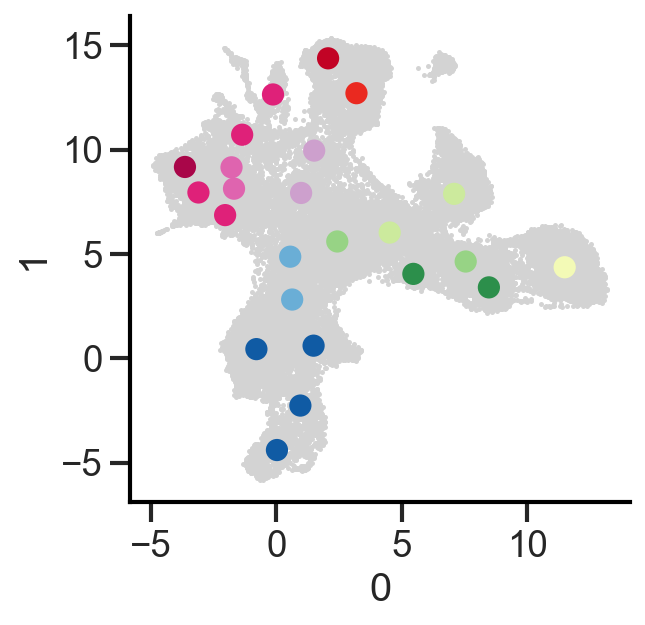

In [76]:
fig, ax = plt.subplots()
sns.scatterplot(data=UMAP_coord_allcells, x=0, y=1, s=5, color='lightgrey', linewidth=0, ax=ax, alpha=1)
sns.scatterplot(data=celltype_pb_meta, x='UMAP1', y='UMAP2', s=100, linewidth=0, ax=ax, hue='lin_day', palette=linday_dict,legend=False)
#sns.scatterplot(data=all_meta[all_meta['step_id']=='120:ect1'], x='UMAP1', y='UMAP2', s=100, linewidth=4, ax=ax, color='Black', legend=False)

sns.despine()
plt.savefig('figures/Fig4b_UMAP.png', dpi=300, format='png', bbox_inches='tight')
plt.show()

In [48]:
#merge annova output with main file
celltype_pb_counts2=celltype_pb_counts.merge(celltype_RNA_an, how='left', left_on=['gene'],right_on=['gene'])
celltype_pb_counts2=celltype_pb_counts2.merge(celltype_K4_an, how='left', left_on=['gene'],right_on=['gene'])
celltype_pb_counts2=celltype_pb_counts2.merge(celltype_K27_an, how='left', left_on=['gene'],right_on=['gene'])

celltype_pb_counts2['RNA_log2']=np.log2(celltype_pb_counts2['RNA']+1)
celltype_pb_counts2['K4_log2']=np.log2(celltype_pb_counts2['K4']+1)
celltype_pb_counts2['K27_log2']=np.log2(celltype_pb_counts2['K27']+1)



In [49]:
#determine threshold based on mixture model

celltype_pb_counts2=binarise_basic(celltype_pb_counts2, 'RNA_log2', 'RNA_state')
celltype_pb_counts2=binarise_basic(celltype_pb_counts2, 'K4_log2', 'K4_state')
celltype_pb_counts2=binarise_basic(celltype_pb_counts2, 'K27_log2', 'K27_state')

#set ...sm_state according to threshold
celltype_pb_counts2.loc[celltype_pb_counts2['RNA']>=(celltype_pb_counts2.loc[celltype_pb_counts2['RNA_state']==1,'RNA'].min()),'RNA_state']=1
celltype_pb_counts2.loc[celltype_pb_counts2['RNA']<(celltype_pb_counts2.loc[celltype_pb_counts2['RNA_state']==1,'RNA'].min()),'RNA_state']=0
celltype_pb_counts2.loc[celltype_pb_counts2['K4']>=(celltype_pb_counts2.loc[celltype_pb_counts2['K4_state']==1,'K4'].min()),'K4_state']=1
celltype_pb_counts2.loc[celltype_pb_counts2['K4']<(celltype_pb_counts2.loc[celltype_pb_counts2['K4_state']==1,'K4'].min()),'K4_state']=0
celltype_pb_counts2.loc[celltype_pb_counts2['K27']>=(celltype_pb_counts2.loc[celltype_pb_counts2['K27_state']==1,'K27'].min()),'K27_state']=1
celltype_pb_counts2.loc[celltype_pb_counts2['K27']<(celltype_pb_counts2.loc[celltype_pb_counts2['K27_state']==1,'K27'].min()),'K27_state']=0

In [50]:
#determine state mean and threshold per gene that will be used for dynmaic genes

RNA_state_mean=pd.DataFrame(celltype_pb_counts2.pivot(index='gene', columns='celltype', values='RNA_state').mean(axis=1))
RNA_state_mean['gene']=RNA_state_mean.index
RNA_state_mean.columns=['RNA_st_mean','gene']
RNA_state_mean=RNA_state_mean.reset_index(drop=True)

K4_state_mean=pd.DataFrame(celltype_pb_counts2.pivot(index='gene', columns='celltype', values='K4_state').mean(axis=1))
K4_state_mean['gene']=K4_state_mean.index
K4_state_mean.columns=['K4_st_mean','gene']
K4_state_mean=K4_state_mean.reset_index(drop=True)

K27_state_mean=pd.DataFrame(celltype_pb_counts2.pivot(index='gene', columns='celltype', values='K27_state').mean(axis=1))
K27_state_mean['gene']=K27_state_mean.index
K27_state_mean.columns=['K27_st_mean','gene']
K27_state_mean=K27_state_mean.reset_index(drop=True)

celltype_pb_counts2=celltype_pb_counts2.merge(RNA_state_mean, how='left', left_on=['gene'],right_on=['gene'])
celltype_pb_counts2=celltype_pb_counts2.merge(K4_state_mean, how='left', left_on=['gene'],right_on=['gene'])
celltype_pb_counts2=celltype_pb_counts2.merge(K27_state_mean, how='left', left_on=['gene'],right_on=['gene'])

In [51]:
celltype_pb_counts2['RNA_gene_state']=np.nan
celltype_pb_counts2['K4_gene_state']=np.nan
celltype_pb_counts2['K27_gene_state']=np.nan



celltype_pb_counts2['RNA_var']=0
celltype_pb_counts2.loc[((celltype_pb_counts2['RNA_p']>2.3)&(celltype_pb_counts2['RNA_fold']>=2)),'RNA_var']=1

celltype_pb_counts2['K4_var']=0
celltype_pb_counts2.loc[((celltype_pb_counts2['K4_p']>2.3)&(celltype_pb_counts2['K4_fold']>=2)),'K4_var']=1

celltype_pb_counts2['K27_var']=0
celltype_pb_counts2.loc[((celltype_pb_counts2['K27_p']>5)&(celltype_pb_counts2['K27_fold']>=3)),'K27_var']=1



celltype_pb_counts2.loc[((celltype_pb_counts2['RNA_var']==0)),'RNA_gene_state']=round(celltype_pb_counts2['RNA_st_mean'])
celltype_pb_counts2.loc[((celltype_pb_counts2['K4_var']==0)),'K4_gene_state']=round(celltype_pb_counts2['K4_st_mean'])
celltype_pb_counts2.loc[((celltype_pb_counts2['K27_var']==0)),'K27_gene_state']=round(celltype_pb_counts2['K27_st_mean'])

celltype_pb_counts2.loc[((celltype_pb_counts2['RNA_var']==1)),'RNA_gene_state']=celltype_pb_counts2['RNA_state']
celltype_pb_counts2.loc[((celltype_pb_counts2['K4_var']==1)),'K4_gene_state']=celltype_pb_counts2['K4_state']
celltype_pb_counts2.loc[((celltype_pb_counts2['K27_var']==1)),'K27_gene_state']=celltype_pb_counts2['K27_state']


In [52]:
#convert sum values into mean, to represent counts per cell
celltype_pb_counts2['RNA_log2']=celltype_pb_counts2['RNA_log2']-np.log2(200)
celltype_pb_counts2['RNA']=celltype_pb_counts2['RNA']/200
celltype_pb_counts2['K4']=celltype_pb_counts2['K4']/200
celltype_pb_counts2['K27']=celltype_pb_counts2['K27']/200


In [53]:
celltype_pb_counts2['K4_log2']=celltype_pb_counts2['K4_log2']-np.log2(200)
celltype_pb_counts2['K27_log2']=celltype_pb_counts2['K27_log2']-np.log2(200)


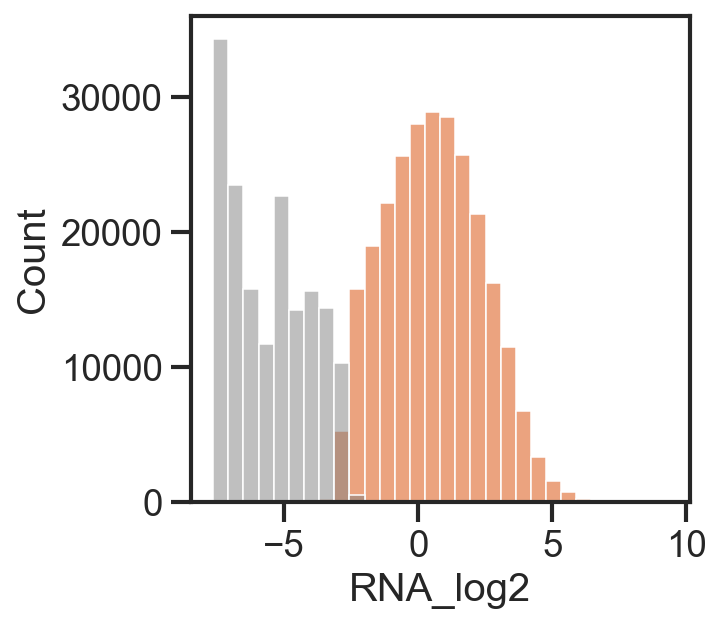

In [54]:
ax=sns.histplot(data=celltype_pb_counts2, x='RNA_log2', hue='RNA_gene_state' ,bins=30, palette=['Grey',Orange], legend=False)

plt.savefig('figures/FigS4b_Bin_hist_RNA_200cell_pb_log.png', dpi=300, format='png', bbox_inches='tight')
plt.show()

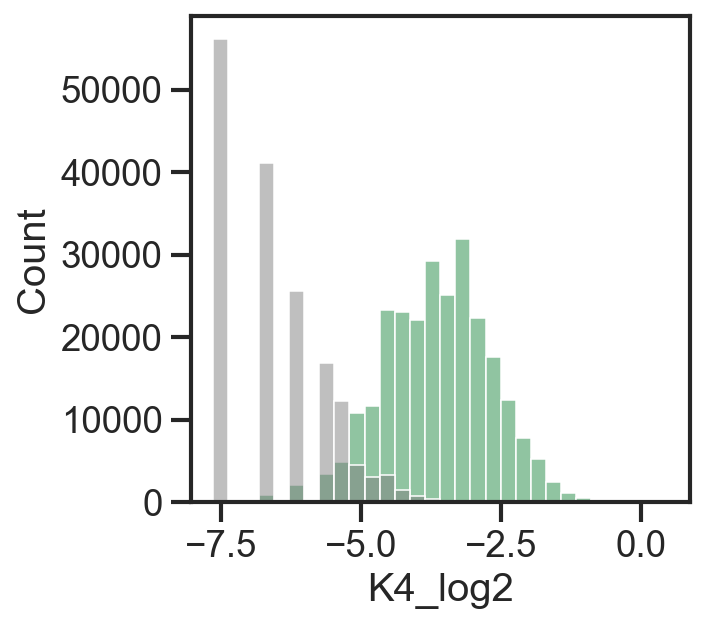

In [55]:
ax=sns.histplot(data=celltype_pb_counts2, x='K4_log2', hue='K4_gene_state' ,bins=30, palette=['Grey',Green], legend=False)

plt.savefig('figures/FigS4b_Bin_hist_K4_200cell_pb_log.png', dpi=300, format='png', bbox_inches='tight')
plt.show()

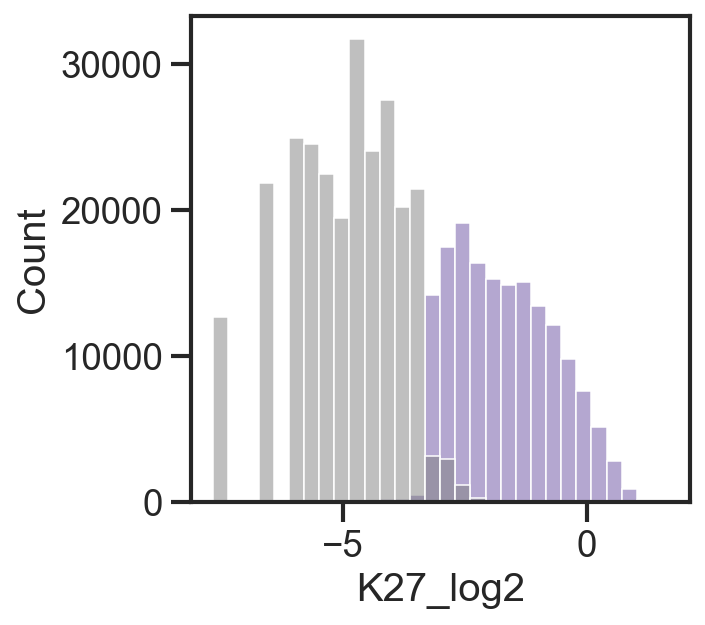

In [56]:
ax=sns.histplot(data=celltype_pb_counts2, x='K27_log2', hue='K27_gene_state' ,bins=30, hue_order=[0,1],palette=['Grey',Purple], legend=False)

plt.savefig('figures/FigS4b_Bin_hist_K27_200cell_pb_log.png', dpi=300, format='png', bbox_inches='tight')
plt.show()

In [57]:
#calculate 8 states
# 1 nunmarked
# 2 K4
# 3 K27
# 4 K4 K27
# 5 RNA
# 6 K4 RNA 
# 7 K27 RNA
# 8 K4 K27 RNA
celltype_pb_counts2['full_state']=9
celltype_pb_counts2.loc[((celltype_pb_counts2['RNA_gene_state']==0)&(celltype_pb_counts2['K4_gene_state']==0)&(celltype_pb_counts2['K27_gene_state']==0)),'full_state']=1
celltype_pb_counts2.loc[((celltype_pb_counts2['RNA_gene_state']==0)&(celltype_pb_counts2['K4_gene_state']==1)&(celltype_pb_counts2['K27_gene_state']==0)),'full_state']=2
celltype_pb_counts2.loc[((celltype_pb_counts2['RNA_gene_state']==0)&(celltype_pb_counts2['K4_gene_state']==0)&(celltype_pb_counts2['K27_gene_state']==1)),'full_state']=3
celltype_pb_counts2.loc[((celltype_pb_counts2['RNA_gene_state']==0)&(celltype_pb_counts2['K4_gene_state']==1)&(celltype_pb_counts2['K27_gene_state']==1)),'full_state']=4
celltype_pb_counts2.loc[((celltype_pb_counts2['RNA_gene_state']==1)&(celltype_pb_counts2['K4_gene_state']==0)&(celltype_pb_counts2['K27_gene_state']==0)),'full_state']=5
celltype_pb_counts2.loc[((celltype_pb_counts2['RNA_gene_state']==1)&(celltype_pb_counts2['K4_gene_state']==1)&(celltype_pb_counts2['K27_gene_state']==0)),'full_state']=6
celltype_pb_counts2.loc[((celltype_pb_counts2['RNA_gene_state']==1)&(celltype_pb_counts2['K4_gene_state']==0)&(celltype_pb_counts2['K27_gene_state']==1)),'full_state']=7
celltype_pb_counts2.loc[((celltype_pb_counts2['RNA_gene_state']==1)&(celltype_pb_counts2['K4_gene_state']==1)&(celltype_pb_counts2['K27_gene_state']==1)),'full_state']=8


# 1 nunmarked
# 2 K4
# 3 RNA
# 4 K4 RNA

celltype_pb_counts2['K4_full_state']=9
celltype_pb_counts2.loc[((celltype_pb_counts2['RNA_gene_state']==0)&(celltype_pb_counts2['K4_gene_state']==0)),'K4_full_state']=1
celltype_pb_counts2.loc[((celltype_pb_counts2['RNA_gene_state']==0)&(celltype_pb_counts2['K4_gene_state']==1)),'K4_full_state']=2
celltype_pb_counts2.loc[((celltype_pb_counts2['RNA_gene_state']==1)&(celltype_pb_counts2['K4_gene_state']==0)),'K4_full_state']=3
celltype_pb_counts2.loc[((celltype_pb_counts2['RNA_gene_state']==1)&(celltype_pb_counts2['K4_gene_state']==1)),'K4_full_state']=4




# 1 nunmarked
# 2 K27
# 3 RNA
# 4 K27 RNA


celltype_pb_counts2['K27_full_state']=9
celltype_pb_counts2.loc[((celltype_pb_counts2['RNA_gene_state']==0)&(celltype_pb_counts2['K27_gene_state']==0)),'K27_full_state']=1
celltype_pb_counts2.loc[((celltype_pb_counts2['RNA_gene_state']==0)&(celltype_pb_counts2['K27_gene_state']==1)),'K27_full_state']=2
celltype_pb_counts2.loc[((celltype_pb_counts2['RNA_gene_state']==1)&(celltype_pb_counts2['K27_gene_state']==0)),'K27_full_state']=3
celltype_pb_counts2.loc[((celltype_pb_counts2['RNA_gene_state']==1)&(celltype_pb_counts2['K27_gene_state']==1)),'K27_full_state']=4


In [58]:
#calculate state fractions
celltype_pb_meta['fr_1']=0
celltype_pb_meta['fr_2']=0
celltype_pb_meta['fr_3']=0
celltype_pb_meta['fr_4']=0
celltype_pb_meta['fr_5']=0
celltype_pb_meta['fr_6']=0
celltype_pb_meta['fr_7']=0
celltype_pb_meta['fr_8']=0
celltype_pb_meta['fr_RNA']=0
celltype_pb_meta['fr_K4']=0
celltype_pb_meta['fr_K27']=0

#celltype_pb_meta.index=celltype_pb_meta['celltype']

celltype_pb_meta['fr_1']=((celltype_pb_counts2.loc[((celltype_pb_counts2['full_state']==1))].groupby('celltype').count()['gene'])/(len(celltype_pb_counts2['gene'].unique())))*100
celltype_pb_meta['fr_2']=((celltype_pb_counts2.loc[((celltype_pb_counts2['full_state']==2))].groupby('celltype').count()['gene'])/(len(celltype_pb_counts2['gene'].unique())))*100
celltype_pb_meta['fr_3']=((celltype_pb_counts2.loc[((celltype_pb_counts2['full_state']==3))].groupby('celltype').count()['gene'])/(len(celltype_pb_counts2['gene'].unique())))*100
celltype_pb_meta['fr_4']=((celltype_pb_counts2.loc[((celltype_pb_counts2['full_state']==4))].groupby('celltype').count()['gene'])/(len(celltype_pb_counts2['gene'].unique())))*100
celltype_pb_meta['fr_5']=((celltype_pb_counts2.loc[((celltype_pb_counts2['full_state']==5))].groupby('celltype').count()['gene'])/(len(celltype_pb_counts2['gene'].unique())))*100
celltype_pb_meta['fr_6']=((celltype_pb_counts2.loc[((celltype_pb_counts2['full_state']==6))].groupby('celltype').count()['gene'])/(len(celltype_pb_counts2['gene'].unique())))*100
celltype_pb_meta['fr_7']=((celltype_pb_counts2.loc[((celltype_pb_counts2['full_state']==7))].groupby('celltype').count()['gene'])/(len(celltype_pb_counts2['gene'].unique())))*100
celltype_pb_meta['fr_8']=((celltype_pb_counts2.loc[((celltype_pb_counts2['full_state']==8))].groupby('celltype').count()['gene'])/(len(celltype_pb_counts2['gene'].unique())))*100
celltype_pb_meta['fr_RNA']=((celltype_pb_counts2.loc[((celltype_pb_counts2['RNA_gene_state']==1))].groupby('celltype').count()['gene'])/(len(celltype_pb_counts2['gene'].unique())))*100
celltype_pb_meta['fr_K4']=((celltype_pb_counts2.loc[((celltype_pb_counts2['K4_gene_state']==1))].groupby('celltype').count()['gene'])/(len(celltype_pb_counts2['gene'].unique())))*100
celltype_pb_meta['fr_K27']=((celltype_pb_counts2.loc[((celltype_pb_counts2['K27_gene_state']==1))].groupby('celltype').count()['gene'])/(len(celltype_pb_counts2['gene'].unique())))*100

celltype_pb_meta['K4_fr_1']=celltype_pb_meta['fr_1']+celltype_pb_meta['fr_3']
celltype_pb_meta['K4_fr_2']=celltype_pb_meta['fr_2']+celltype_pb_meta['fr_4']
celltype_pb_meta['K4_fr_3']=celltype_pb_meta['fr_5']+celltype_pb_meta['fr_7']
celltype_pb_meta['K4_fr_4']=celltype_pb_meta['fr_6']+celltype_pb_meta['fr_8']


celltype_pb_meta['K27_fr_1']=celltype_pb_meta['fr_1']+celltype_pb_meta['fr_2']
celltype_pb_meta['K27_fr_2']=celltype_pb_meta['fr_3']+celltype_pb_meta['fr_4']
celltype_pb_meta['K27_fr_3']=celltype_pb_meta['fr_5']+celltype_pb_meta['fr_6']
celltype_pb_meta['K27_fr_4']=celltype_pb_meta['fr_7']+celltype_pb_meta['fr_8']

    

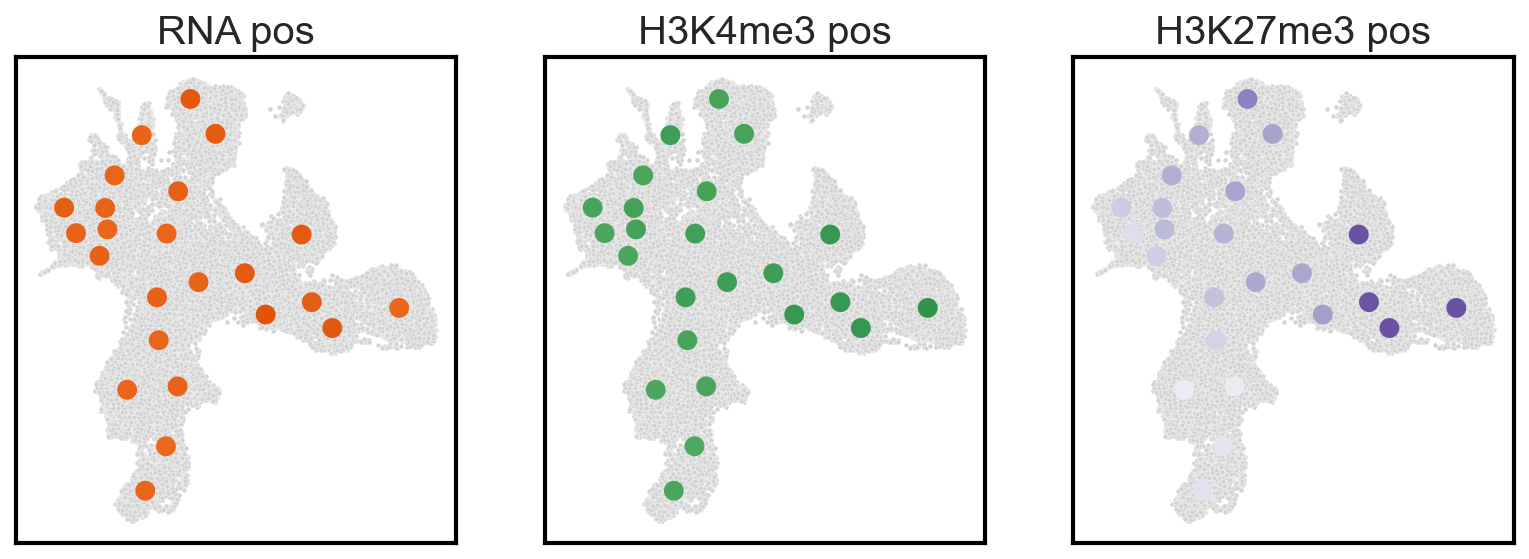

In [59]:

sns.set_context("talk", font_scale=1)
sns.set_style("whitegrid", {'axes.grid' : False, 'xtick.bottom': True,
 'ytick.left': True, 'axes.edgecolor': 'black'})

col='Greys'

fig, axes = plt.subplots(1, 3, figsize=(12, 4), gridspec_kw={})
#plt.figure(figsize=(40,200))
axes = axes.flatten()
#fig.tight_layout(pad=0)




sns.scatterplot(data=UMAP_coord_allcells, x=0, y=1, s=5, color='lightgrey', ax=axes[0], alpha=1)
sns.scatterplot(data=celltype_pb_meta, x='UMAP1', y='UMAP2', s=80, palette=oranges, hue='fr_RNA', ax=axes[0], linewidth=0, hue_norm=(0,70), legend=False)
axes[0].tick_params(labelbottom=False, bottom=False)
axes[0].tick_params(labelleft=False, left=False)
axes[0].set(xlabel='',
       ylabel='',
       title='RNA pos')


sns.scatterplot(data=UMAP_coord_allcells, x=0, y=1, s=5, color='lightgrey', ax=axes[1], alpha=1)
sns.scatterplot(data=celltype_pb_meta, x='UMAP1', y='UMAP2', s=80, palette=greens, hue='fr_K4', ax=axes[1], linewidth=0, hue_norm=(0,70), legend=False)
axes[1].tick_params(labelbottom=False, bottom=False)
axes[1].tick_params(labelleft=False, left=False)
axes[1].set(xlabel='',
       ylabel='',
       title='H3K4me3 pos')

sns.scatterplot(data=UMAP_coord_allcells, x=0, y=1, s=5, color='lightgrey', ax=axes[2], alpha=1)
sns.scatterplot(data=celltype_pb_meta, x='UMAP1', y='UMAP2', s=80, palette=purples, hue='fr_K27', ax=axes[2], linewidth=0, hue_norm=(0,70), legend=False)
axes[2].tick_params(labelbottom=False, bottom=False)
axes[2].tick_params(labelleft=False, left=False)
axes[2].set(xlabel='',
       ylabel='',
       title='H3K27me3 pos')





plt.savefig('figures/FigS4c_UMAP_3_states_200cells_pb_dif_color.png', dpi=300, format='png', bbox_inches='tight')
plt.show()



In [60]:
#plot example heatmaps of 3 data layers split by class
def stepheatmap_K4(stepsel):

    RNAlayerlog='RNA_log2'
    K4layer='K4'
    K27layer='K27'
    
    
    plotdata=celltype_pb_counts2.loc[celltype_pb_counts2['celltype']==stepsel].copy()

    
    l1=plotdata[((plotdata['RNA_gene_state']==0)&(plotdata['K4_gene_state']==0))]['gene']
    l2=plotdata[((plotdata['RNA_gene_state']==0)&(plotdata['K4_gene_state']==1))]['gene']
    l3=plotdata[((plotdata['RNA_gene_state']==1)&(plotdata['K4_gene_state']==0))]['gene']
    l4=plotdata[((plotdata['RNA_gene_state']==1)&(plotdata['K4_gene_state']==1))]['gene']
    

    
    sns.set_context("talk", font_scale=1)
    sns.set_style("whitegrid", {'axes.grid' : False, 'xtick.bottom': True,
     'ytick.left': True, 'axes.edgecolor': 'black'})
    
    pc=0.001
    fig, axes = plt.subplots(5, 2, figsize=(6, 20), gridspec_kw={'hspace': 0.02 ,'width_ratios':(1,1),'height_ratios':(len(l1)+pc,len(l2)+pc,len(l3)+pc,len(l4)+pc,200)})
    #plt.figure(figsize=(40,200))
    axes = axes.flatten()
    #fig.tight_layout(pad=0)
    
    
    RNAvmaxlog=(celltype_pb_counts2[RNAlayerlog]).quantile(q=1)
    RNAvminlog=(celltype_pb_counts2[RNAlayerlog]).min()
    k4vmax=(celltype_pb_counts2[K4layer]).quantile(q=0.95)
    k27vmax=(celltype_pb_counts2[K27layer]).quantile(q=0.95)
    
    
    
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l1)),RNAlayerlog].values.reshape((1, -1)).T, ax=axes[0], cmap=oranges_r, cbar=False, vmin=RNAvminlog, vmax=RNAvmaxlog)
    axes[0].tick_params(labelleft=False, left=False)
    axes[0].tick_params(labelbottom=False, bottom=False)
    axes[0].set(xlabel='',
           ylabel='',
           title='')
    

    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l1)),K4layer].values.reshape((1, -1)).T, ax=axes[1], cmap=greens_r, cbar=False, vmin=0, vmax=k4vmax)
    axes[1].tick_params(labelleft=False, left=False)
    axes[1].tick_params(labelbottom=False, bottom=False)
    axes[1].set(xlabel='',
           ylabel='',
           title='')
    
    
    
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l2)),RNAlayerlog].values.reshape((1, -1)).T, ax=axes[2], cmap=oranges_r, cbar=False, vmin=RNAvminlog, vmax=RNAvmaxlog)
    axes[2].tick_params(labelleft=False, left=False)
    axes[2].tick_params(labelbottom=False, bottom=False)
    axes[2].set(xlabel='',
           ylabel='',
           title='')
    
    
    
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l2)),K4layer].values.reshape((1, -1)).T, ax=axes[3], cmap=greens_r, cbar=False, vmin=0, vmax=k4vmax)
    axes[3].tick_params(labelleft=False, left=False)
    axes[3].tick_params(labelbottom=False, bottom=False)
    axes[3].set(xlabel='',
           ylabel='',
           title='')
    

    
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l3)),RNAlayerlog].values.reshape((1, -1)).T, ax=axes[4], cmap=oranges_r, cbar=False, vmin=RNAvminlog, vmax=RNAvmaxlog)
    axes[4].tick_params(labelleft=False, left=False)
    axes[4].tick_params(labelbottom=False, bottom=False)
    axes[4].set(xlabel='',
           ylabel='',
           title='')
    
   
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l3)),K4layer].values.reshape((1, -1)).T, ax=axes[5], cmap=greens_r, cbar=False, vmin=0, vmax=k4vmax)
    axes[5].tick_params(labelleft=False, left=False)
    axes[5].tick_params(labelbottom=False, bottom=False)
    axes[5].set(xlabel='',
           ylabel='',
           title='')
    
    
    
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l4)),RNAlayerlog].values.reshape((1, -1)).T, ax=axes[6], cmap=oranges_r, cbar=False, vmin=RNAvminlog, vmax=RNAvmaxlog)
    axes[6].tick_params(labelleft=False, left=False)
    axes[6].tick_params(labelbottom=False, bottom=False)
    axes[6].set(xlabel='',
           ylabel='',
           title='')
    
   
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l4)),K4layer].values.reshape((1, -1)).T, ax=axes[7], cmap=greens_r, cbar=False, vmin=0, vmax=k4vmax)
    axes[7].tick_params(labelleft=False, left=False)
    axes[7].tick_params(labelbottom=False, bottom=False)
    axes[7].set(xlabel='',
           ylabel='',
           title='')
    
    
    
   
    
    
    gradient = np.linspace(round(RNAvminlog,0), round(RNAvmaxlog,0)).reshape(1, -1)
    axes[8].imshow(gradient, aspect="auto", cmap=oranges_r)
    axes[8].set_yticks([])
    axes[8].set_frame_on(False)
    axes[8].set_xticks([0, gradient.size-1])  # Positions along the gradient
    axes[8].set_xticklabels([round(RNAvminlog,0), round(RNAvmaxlog,0)])  # Labels
    
    
    
    gradient = np.linspace(0, round(k4vmax,1)).reshape(1, -1)
    axes[9].imshow(gradient, aspect="auto", cmap=greens_r)
    axes[9].set_yticks([])
    axes[9].set_frame_on(False)
    axes[9].set_xticks([0, gradient.size-1])  # Positions along the gradient
    axes[9].set_xticklabels([0, round(k4vmax,1)])  # Labels
    
    
    
    filename1='figures/Fig4b_Stateheatmap_K4_'+stepsel+'.png'
    filename2='figures/Fig4b_Stateheatmap_K4_'+stepsel+'.pdf'
    
    plt.savefig(filename1, dpi=300, format='png', bbox_inches='tight')
    plt.savefig(filename2, dpi=300, format='pdf', bbox_inches='tight')
    plt.show()

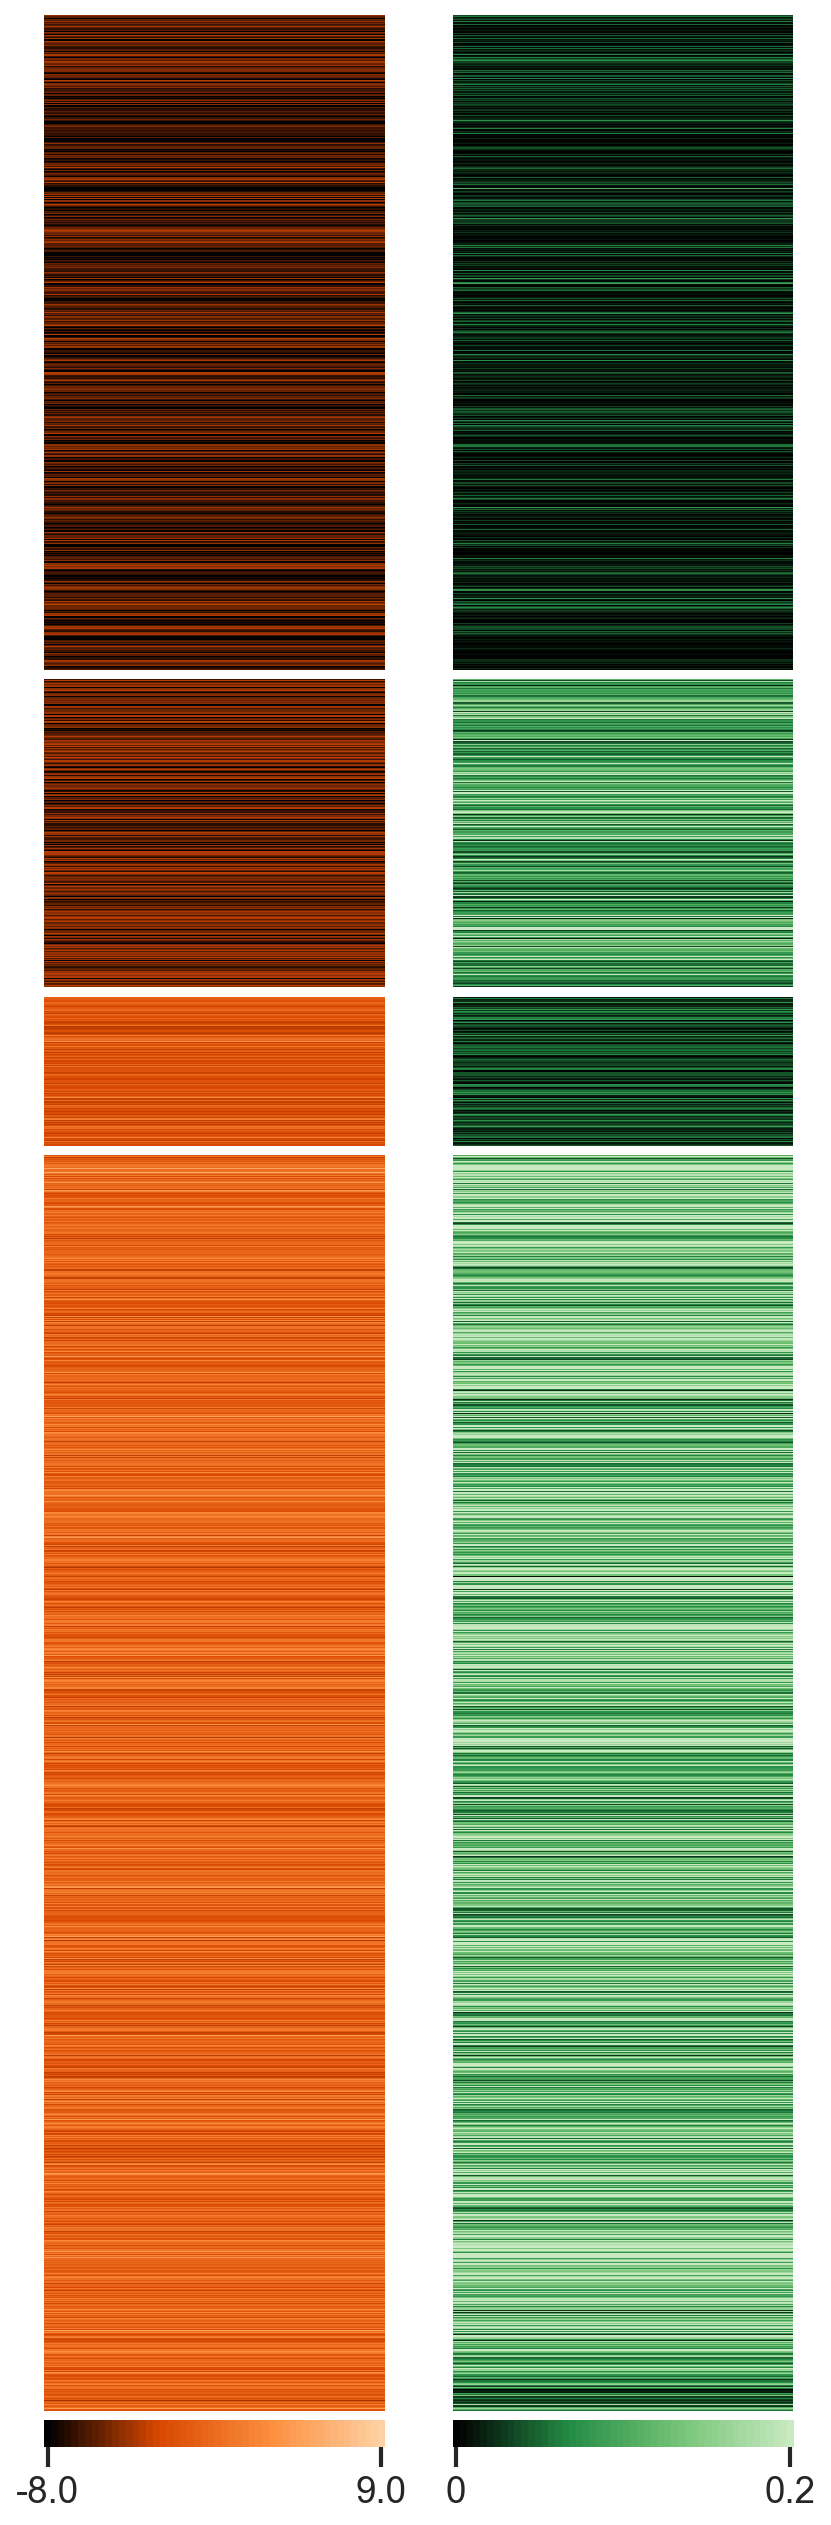

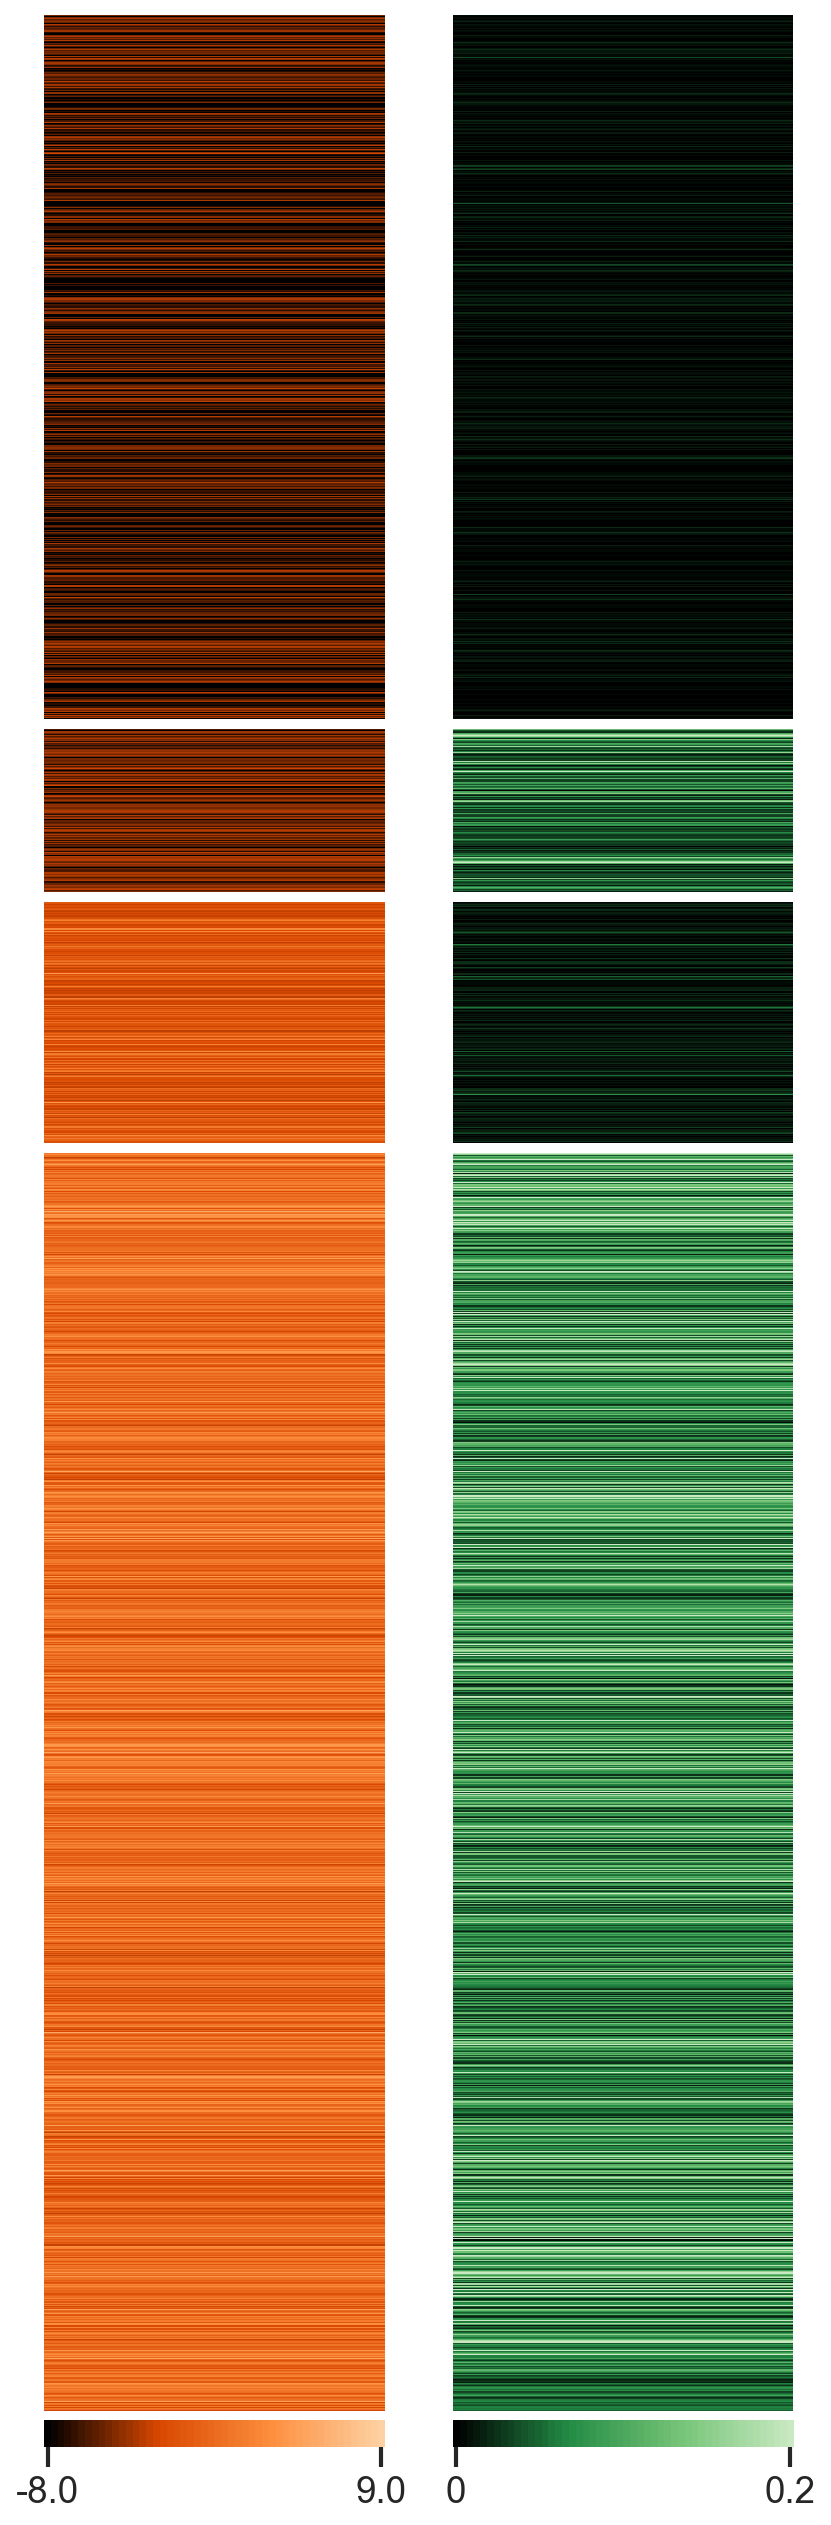

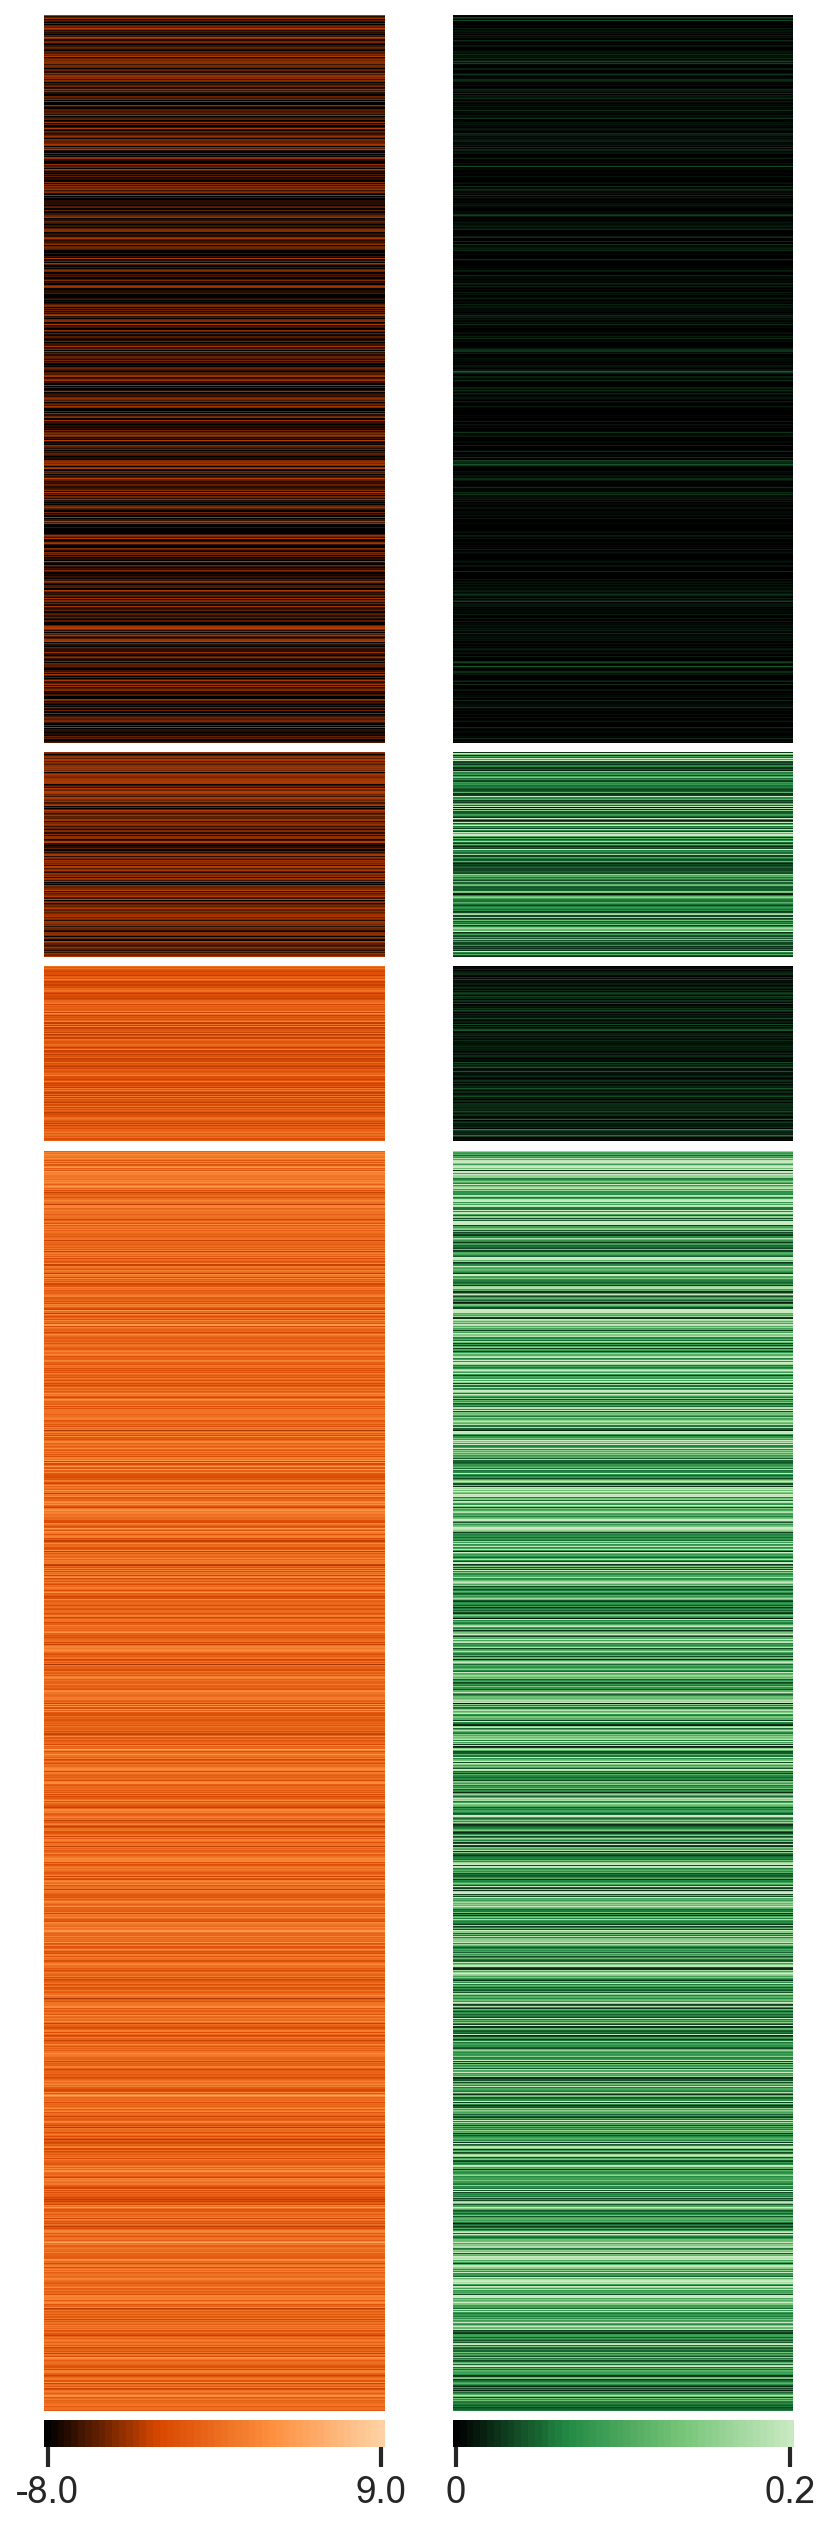

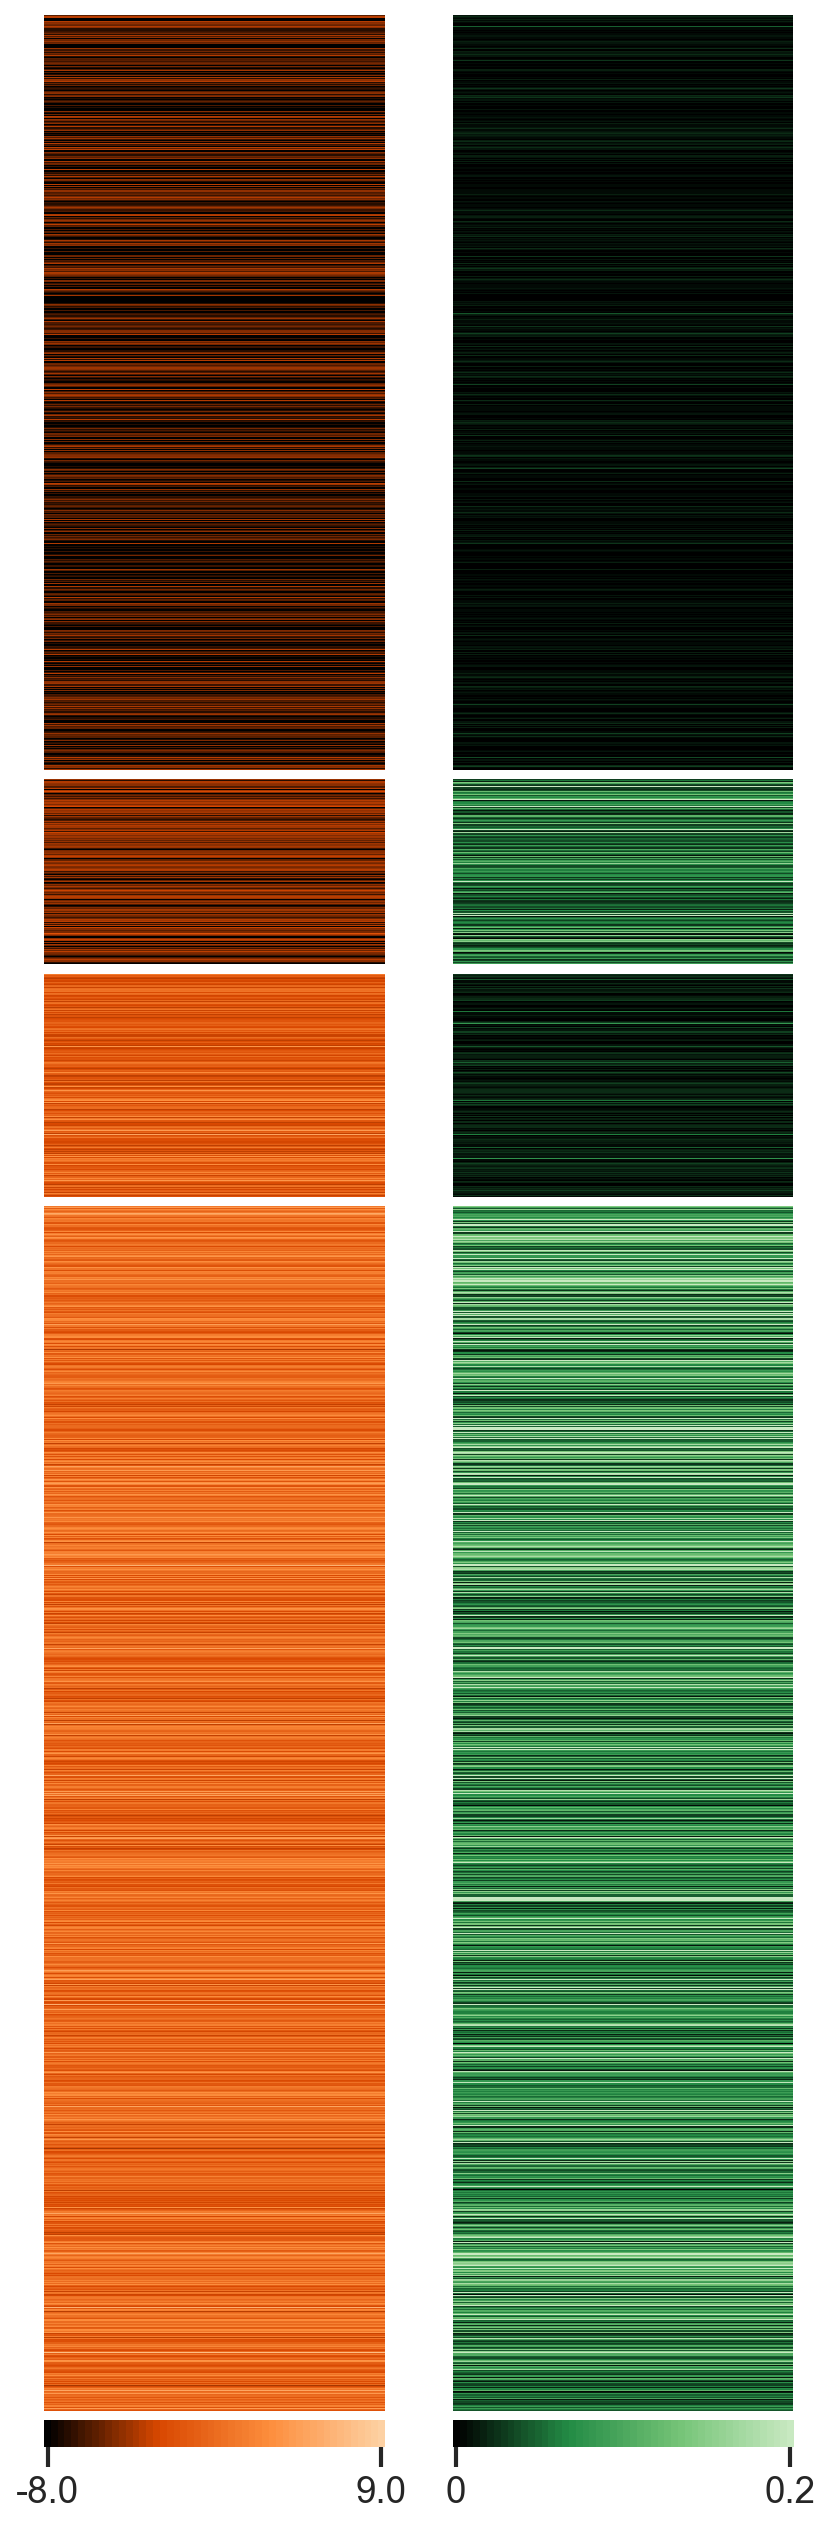

In [61]:
stepheatmap_K4(stepsel='mESCs')
stepheatmap_K4(stepsel='Visceral Endoderm')
stepheatmap_K4(stepsel='Caudal Mesoderm')
stepheatmap_K4(stepsel='Late Motor Neurons')

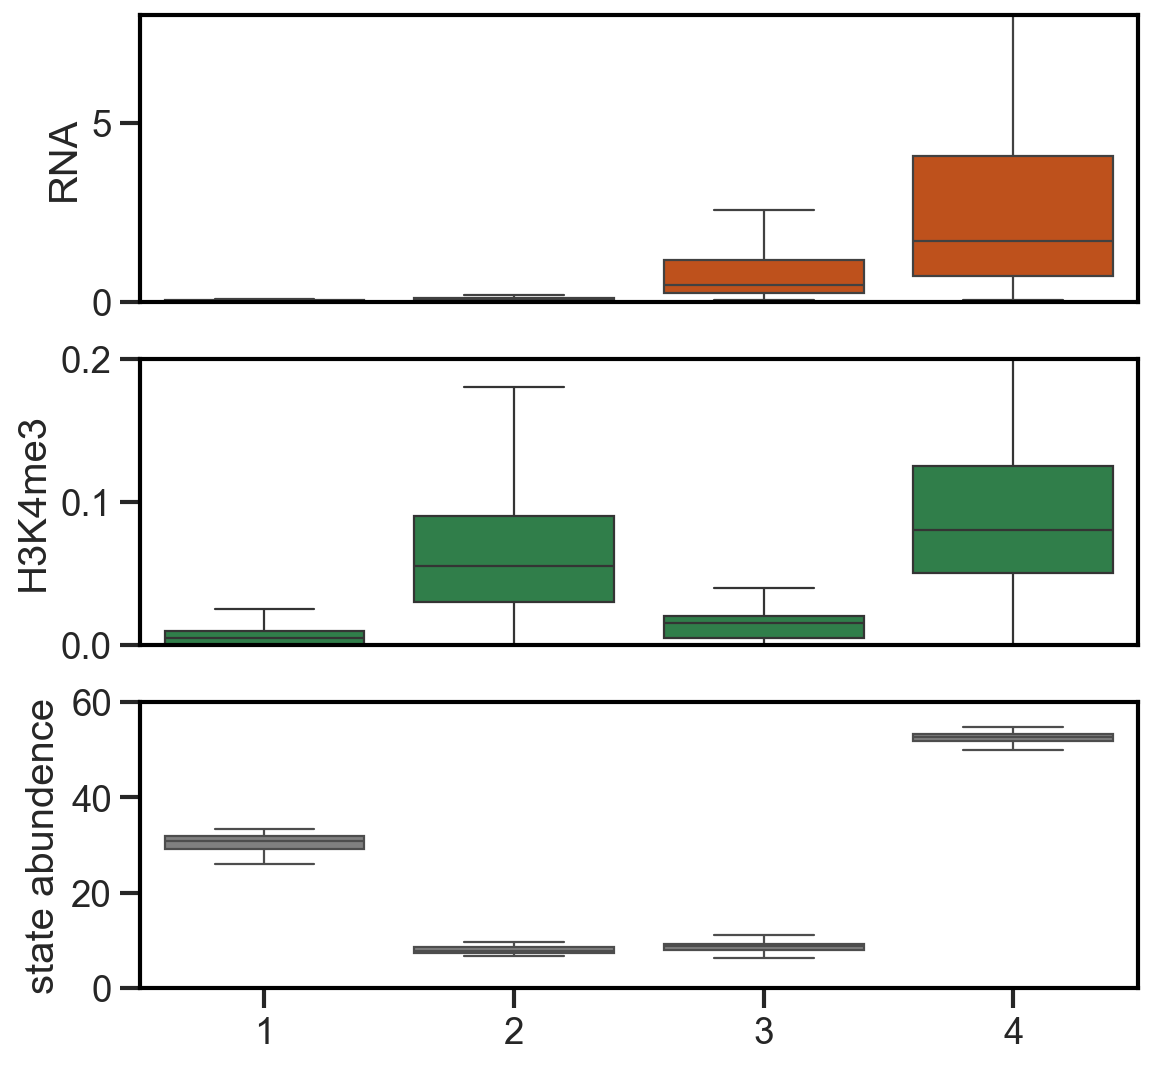

In [62]:

sns.set_context("talk", font_scale=1)
sns.set_style("whitegrid", {'axes.grid' : False, 'xtick.bottom': True,
 'ytick.left': True, 'axes.edgecolor': 'black'})

col='Greys'

fig, axes = plt.subplots(3, 1, figsize=(8, 8), gridspec_kw={})
#plt.figure(figsize=(40,200))
axes = axes.flatten()
#fig.tight_layout(pad=0)




sns.boxplot(data=celltype_pb_counts2, x='K4_full_state', y='RNA', color=Orange, ax=axes[0], fliersize=0)
axes[0].tick_params(labelbottom=False, bottom=False)
axes[0].set_ylim(0, 8)
#axes[0].tick_params(labelleft=False, left=False)
axes[0].set(xlabel='',
       ylabel='RNA',
       title='')


sns.boxplot(data=celltype_pb_counts2, x='K4_full_state', y='K4', color=Green, ax=axes[1], fliersize=0)
axes[1].tick_params(labelbottom=False, bottom=False)
axes[1].set_ylim(0, 0.2)
#axes[0].tick_params(labelleft=False, left=False)
axes[1].set(xlabel='',
       ylabel='H3K4me3',
       title='')



plotdata=pd.melt(celltype_pb_meta, id_vars=['celltype'], value_vars=['K4_fr_1','K4_fr_2','K4_fr_3','K4_fr_4'])
plotdata['index']=0
plotdata.loc[plotdata['variable']=='K4_fr_1','index']=1
plotdata.loc[plotdata['variable']=='K4_fr_2','index']=2
plotdata.loc[plotdata['variable']=='K4_fr_3','index']=3
plotdata.loc[plotdata['variable']=='K4_fr_4','index']=4



sns.boxplot(data=plotdata, x='index', y='value', color='Grey', ax=axes[2], fliersize=0)
#axes[3].tick_params(labelbottom=False, bottom=False)
axes[2].set_ylim(0, 60)
#axes[0].tick_params(labelleft=False, left=False)
axes[2].set(xlabel='',
       ylabel='state abundence',
       title='')

plt.savefig('figures/FigS4d_Box_plot_K4_genestates.pdf', dpi=300, format='pdf', bbox_inches='tight')
plt.show()



In [63]:
#plot example heatmaps of 3 data layers split by class
def stepheatmap_K27(stepsel):

    RNAlayerlog='RNA_log2'
    K4layer='K4'
    K27layer='K27'
    
    
    plotdata=celltype_pb_counts2.loc[celltype_pb_counts2['celltype']==stepsel].copy()

    
    l1=plotdata[((plotdata['RNA_gene_state']==0)&(plotdata['K27_gene_state']==0))]['gene']
    l2=plotdata[((plotdata['RNA_gene_state']==0)&(plotdata['K27_gene_state']==1))]['gene']
    l3=plotdata[((plotdata['RNA_gene_state']==1)&(plotdata['K27_gene_state']==0))]['gene']
    l4=plotdata[((plotdata['RNA_gene_state']==1)&(plotdata['K27_gene_state']==1))]['gene']
    

    
    sns.set_context("talk", font_scale=1)
    sns.set_style("whitegrid", {'axes.grid' : False, 'xtick.bottom': True,
     'ytick.left': True, 'axes.edgecolor': 'black'})
    
    pc=0.001
    fig, axes = plt.subplots(5, 2, figsize=(6, 20), gridspec_kw={'hspace': 0.02 ,'width_ratios':(1,1),'height_ratios':(len(l1)+pc,len(l2)+pc,len(l3)+pc,len(l4)+pc,200)})
    #plt.figure(figsize=(40,200))
    axes = axes.flatten()
    #fig.tight_layout(pad=0)
    
    
    RNAvmaxlog=(celltype_pb_counts2[RNAlayerlog]).quantile(q=1)
    RNAvminlog=(celltype_pb_counts2[RNAlayerlog]).min()
    k4vmax=(celltype_pb_counts2[K4layer]).quantile(q=0.95)
    k27vmax=(celltype_pb_counts2[K27layer]).quantile(q=0.97)
    
    
    
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l1)),RNAlayerlog].values.reshape((1, -1)).T, ax=axes[0], cmap=oranges_r, cbar=False, vmin=RNAvminlog, vmax=RNAvmaxlog)
    axes[0].tick_params(labelleft=False, left=False)
    axes[0].tick_params(labelbottom=False, bottom=False)
    axes[0].set(xlabel='',
           ylabel='',
           title='')
    
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l1)),K27layer].values.reshape((1, -1)).T, ax=axes[1], cmap=purples_r, cbar=False, vmin=0, vmax=k27vmax)
    axes[1].tick_params(labelleft=False, left=False)
    axes[1].tick_params(labelbottom=False, bottom=False)
    axes[1].set(xlabel='',
           ylabel='',
           title='')
    
    
    
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l2)),RNAlayerlog].values.reshape((1, -1)).T, ax=axes[2], cmap=oranges_r, cbar=False, vmin=RNAvminlog, vmax=RNAvmaxlog)
    axes[2].tick_params(labelleft=False, left=False)
    axes[2].tick_params(labelbottom=False, bottom=False)
    axes[2].set(xlabel='',
           ylabel='',
           title='')
    
    
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l2)),K27layer].values.reshape((1, -1)).T, ax=axes[3], cmap=purples_r, cbar=False, vmin=0, vmax=k27vmax)
    axes[3].tick_params(labelleft=False, left=False)
    axes[3].tick_params(labelbottom=False, bottom=False)
    axes[3].set(xlabel='',
           ylabel='',
           title='')
    

    
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l3)),RNAlayerlog].values.reshape((1, -1)).T, ax=axes[4], cmap=oranges_r, cbar=False, vmin=RNAvminlog, vmax=RNAvmaxlog)
    axes[4].tick_params(labelleft=False, left=False)
    axes[4].tick_params(labelbottom=False, bottom=False)
    axes[4].set(xlabel='',
           ylabel='',
           title='')
    

    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l3)),K27layer].values.reshape((1, -1)).T, ax=axes[5], cmap=purples_r, cbar=False, vmin=0, vmax=k27vmax)
    axes[5].tick_params(labelleft=False, left=False)
    axes[5].tick_params(labelbottom=False, bottom=False)
    axes[5].set(xlabel='',
           ylabel='',
           title='')
    
    
    
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l4)),RNAlayerlog].values.reshape((1, -1)).T, ax=axes[6], cmap=oranges_r, cbar=False, vmin=RNAvminlog, vmax=RNAvmaxlog)
    axes[6].tick_params(labelleft=False, left=False)
    axes[6].tick_params(labelbottom=False, bottom=False)
    axes[6].set(xlabel='',
           ylabel='',
           title='')
    

    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l4)),K27layer].values.reshape((1, -1)).T, ax=axes[7], cmap=purples_r, cbar=False, vmin=0, vmax=k27vmax)
    axes[7].tick_params(labelleft=False, left=False)
    axes[7].tick_params(labelbottom=False, bottom=False)
    axes[7].set(xlabel='',
           ylabel='',
           title='')
    
    
    
   
    
    
    gradient = np.linspace(round(RNAvminlog,0), round(RNAvmaxlog,0)).reshape(1, -1)
    axes[8].imshow(gradient, aspect="auto", cmap=oranges_r)
    axes[8].set_yticks([])
    axes[8].set_frame_on(False)
    axes[8].set_xticks([0, gradient.size-1])  # Positions along the gradient
    axes[8].set_xticklabels([round(RNAvminlog,0), round(RNAvmaxlog,0)])  # Labels
    

    
    gradient = np.linspace(0, round(k27vmax,1)).reshape(1, -1)
    axes[9].imshow(gradient, aspect="auto", cmap=purples_r)
    axes[9].set_yticks([])
    axes[9].set_frame_on(False)
    axes[9].set_xticks([0, gradient.size-1])  # Positions along the gradient
    axes[9].set_xticklabels([0, round(k27vmax,1)])  # Labels
    
    
    
    filename1='figures/Fig4c_Stateheatmap_K27_'+stepsel+'.png'
    filename2='figures/Fig4c_Stateheatmap_K27_'+stepsel+'.pdf'
    
    plt.savefig(filename1, dpi=300, format='png', bbox_inches='tight')
    plt.savefig(filename2, dpi=300, format='pdf', bbox_inches='tight')
    plt.show()

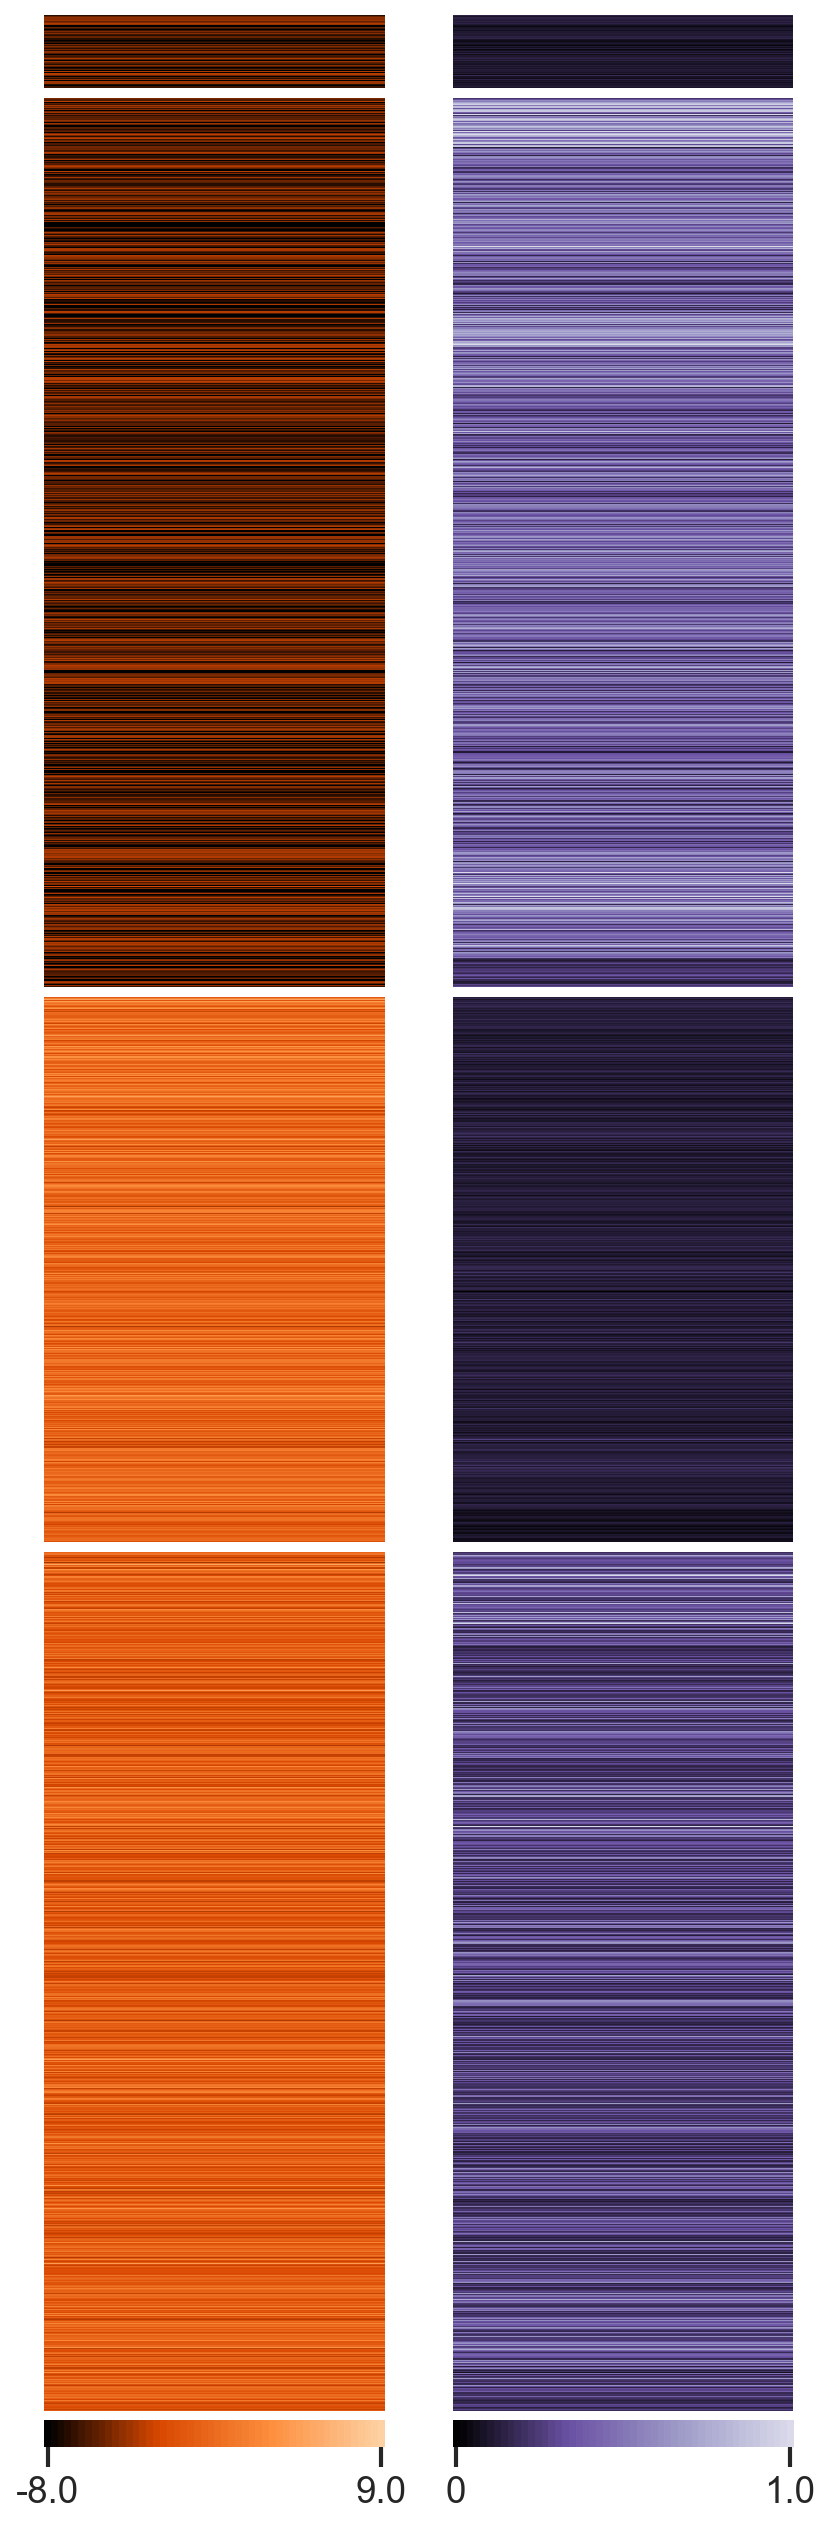

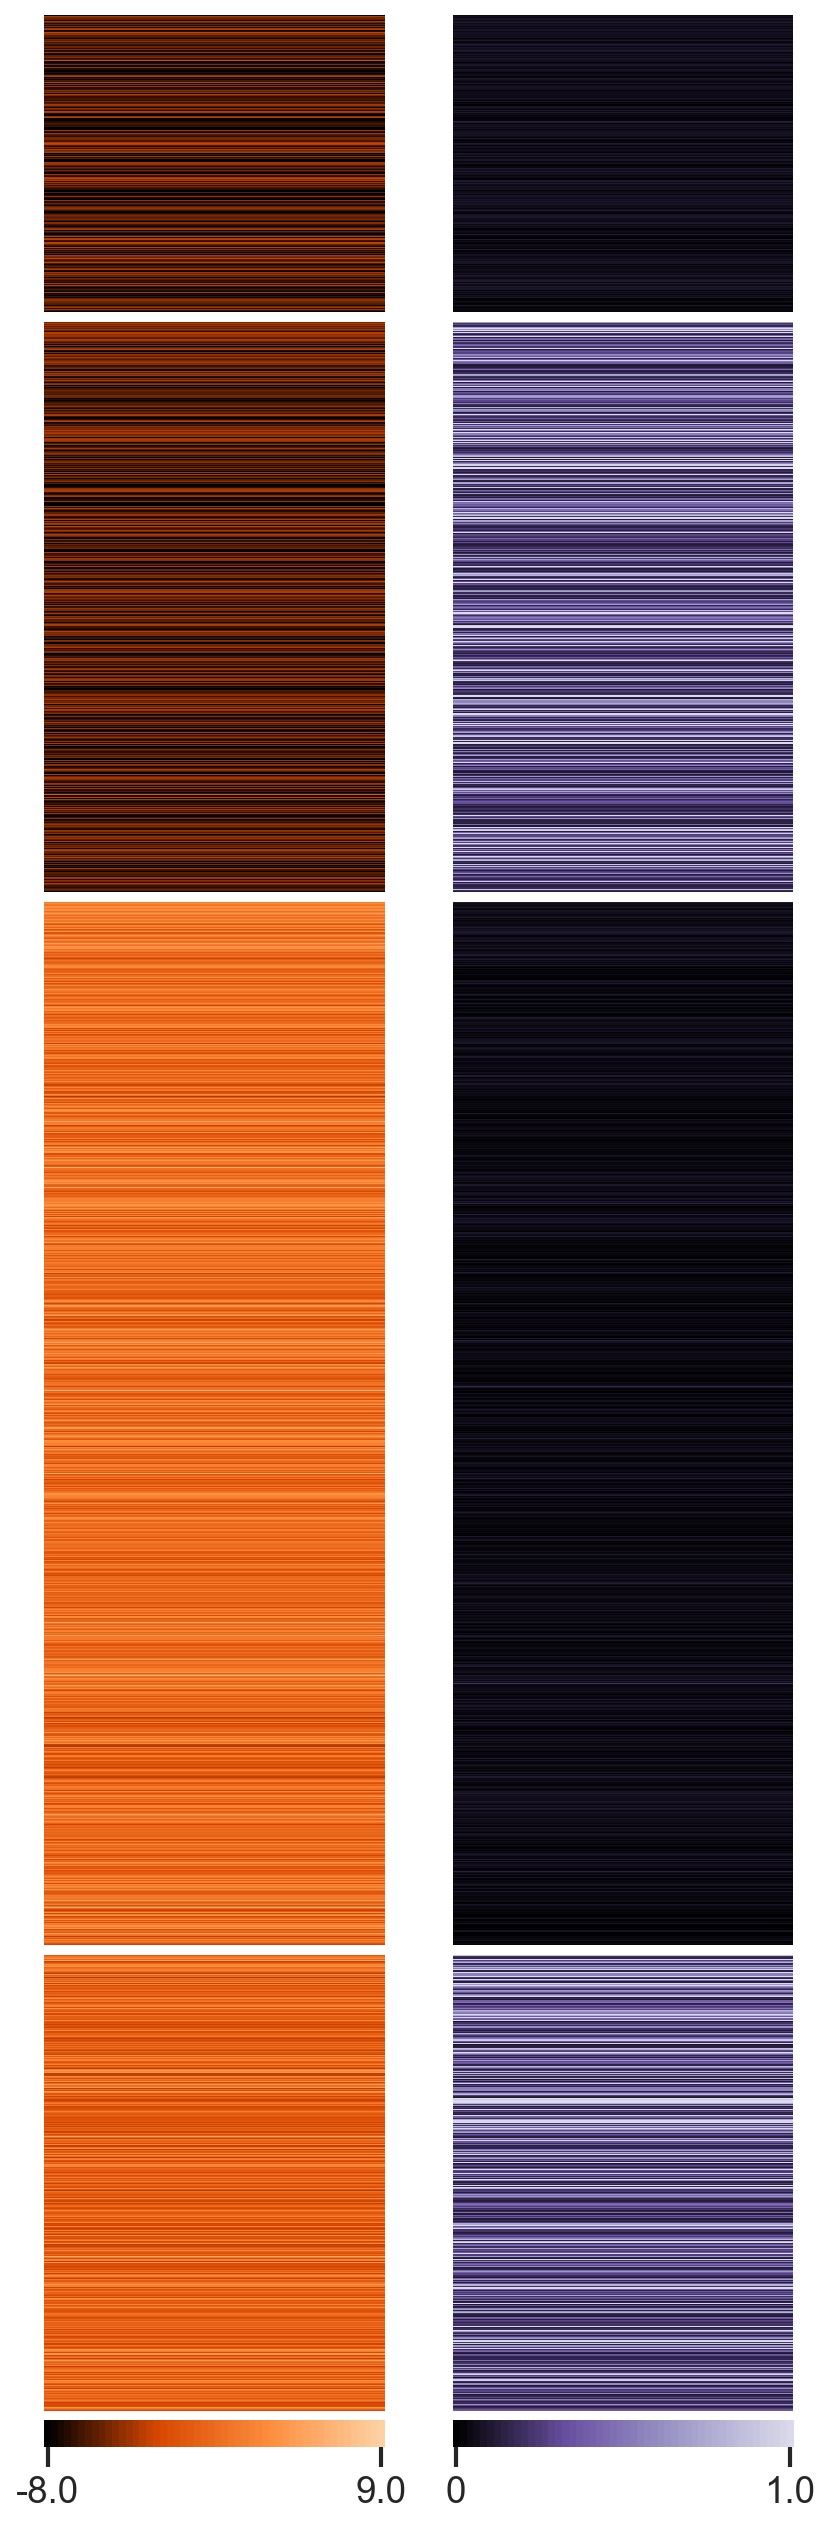

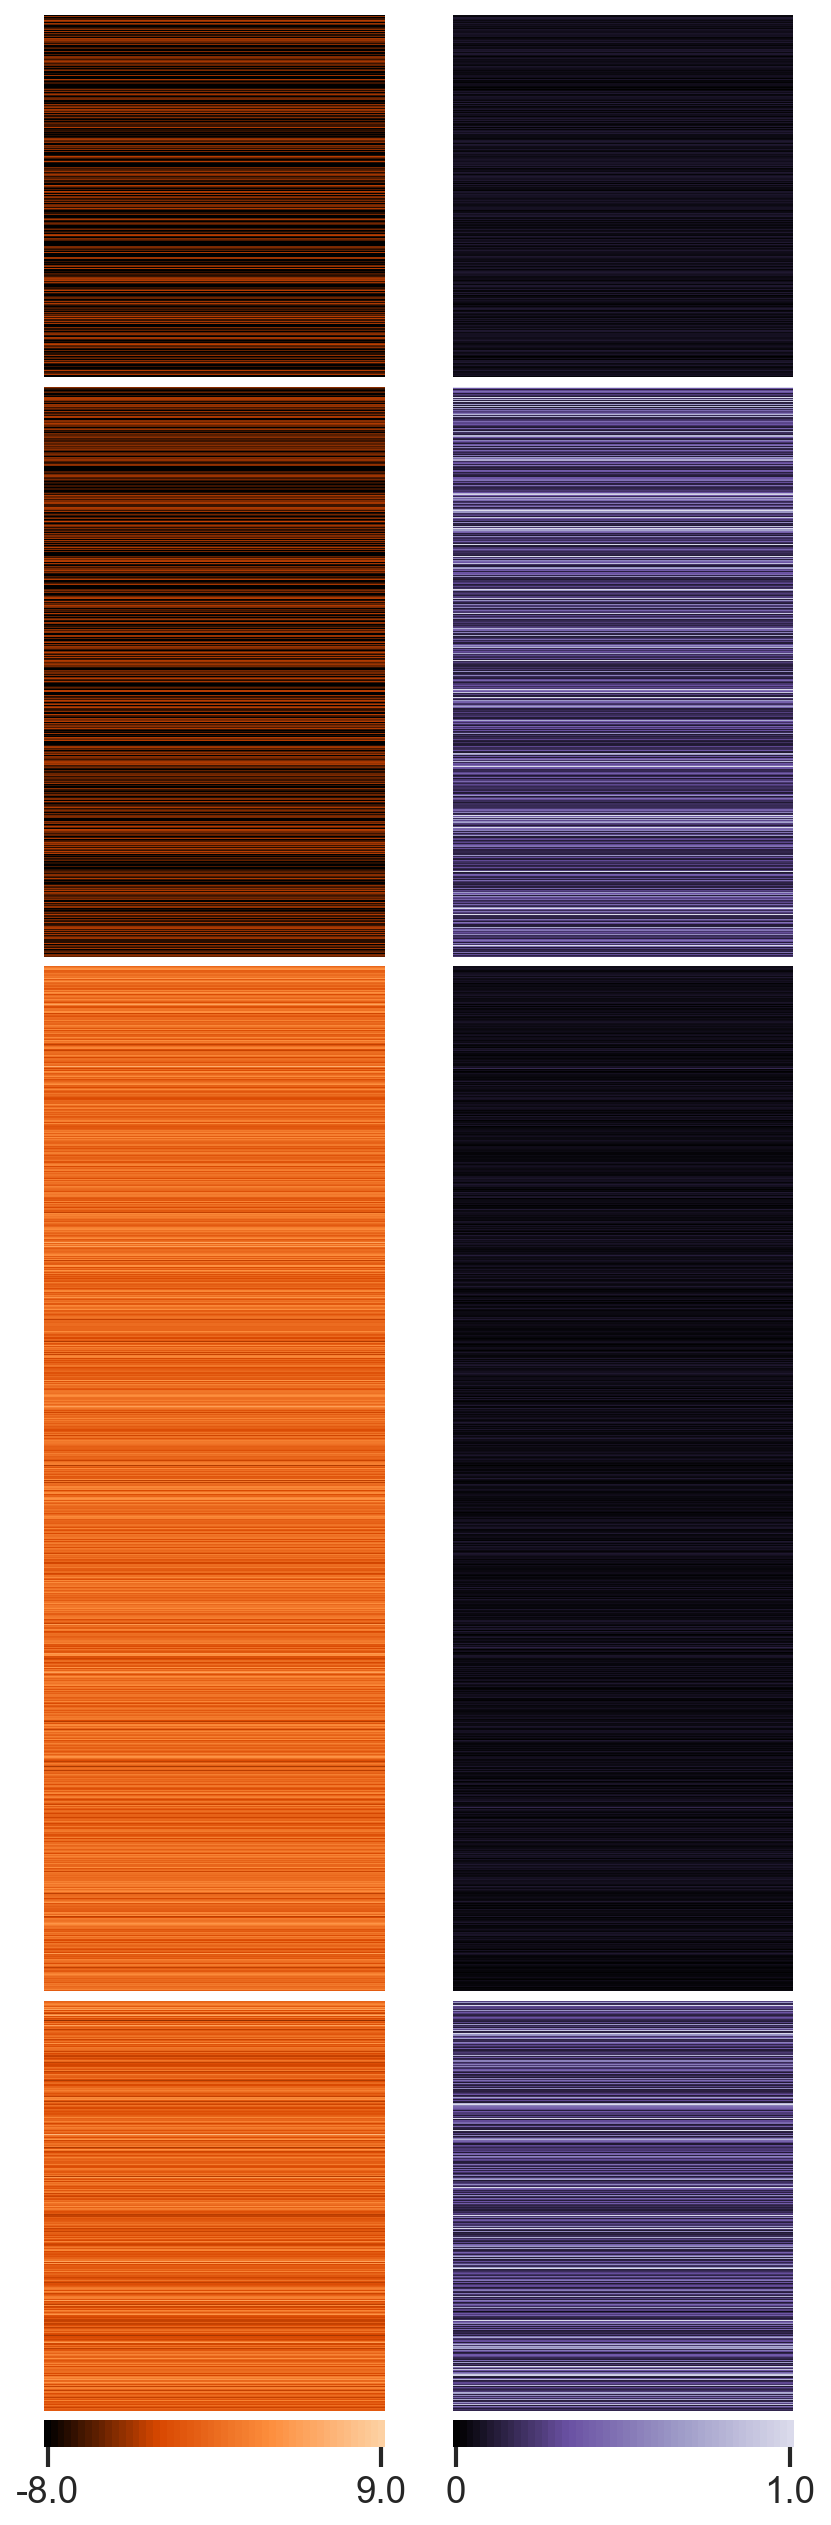

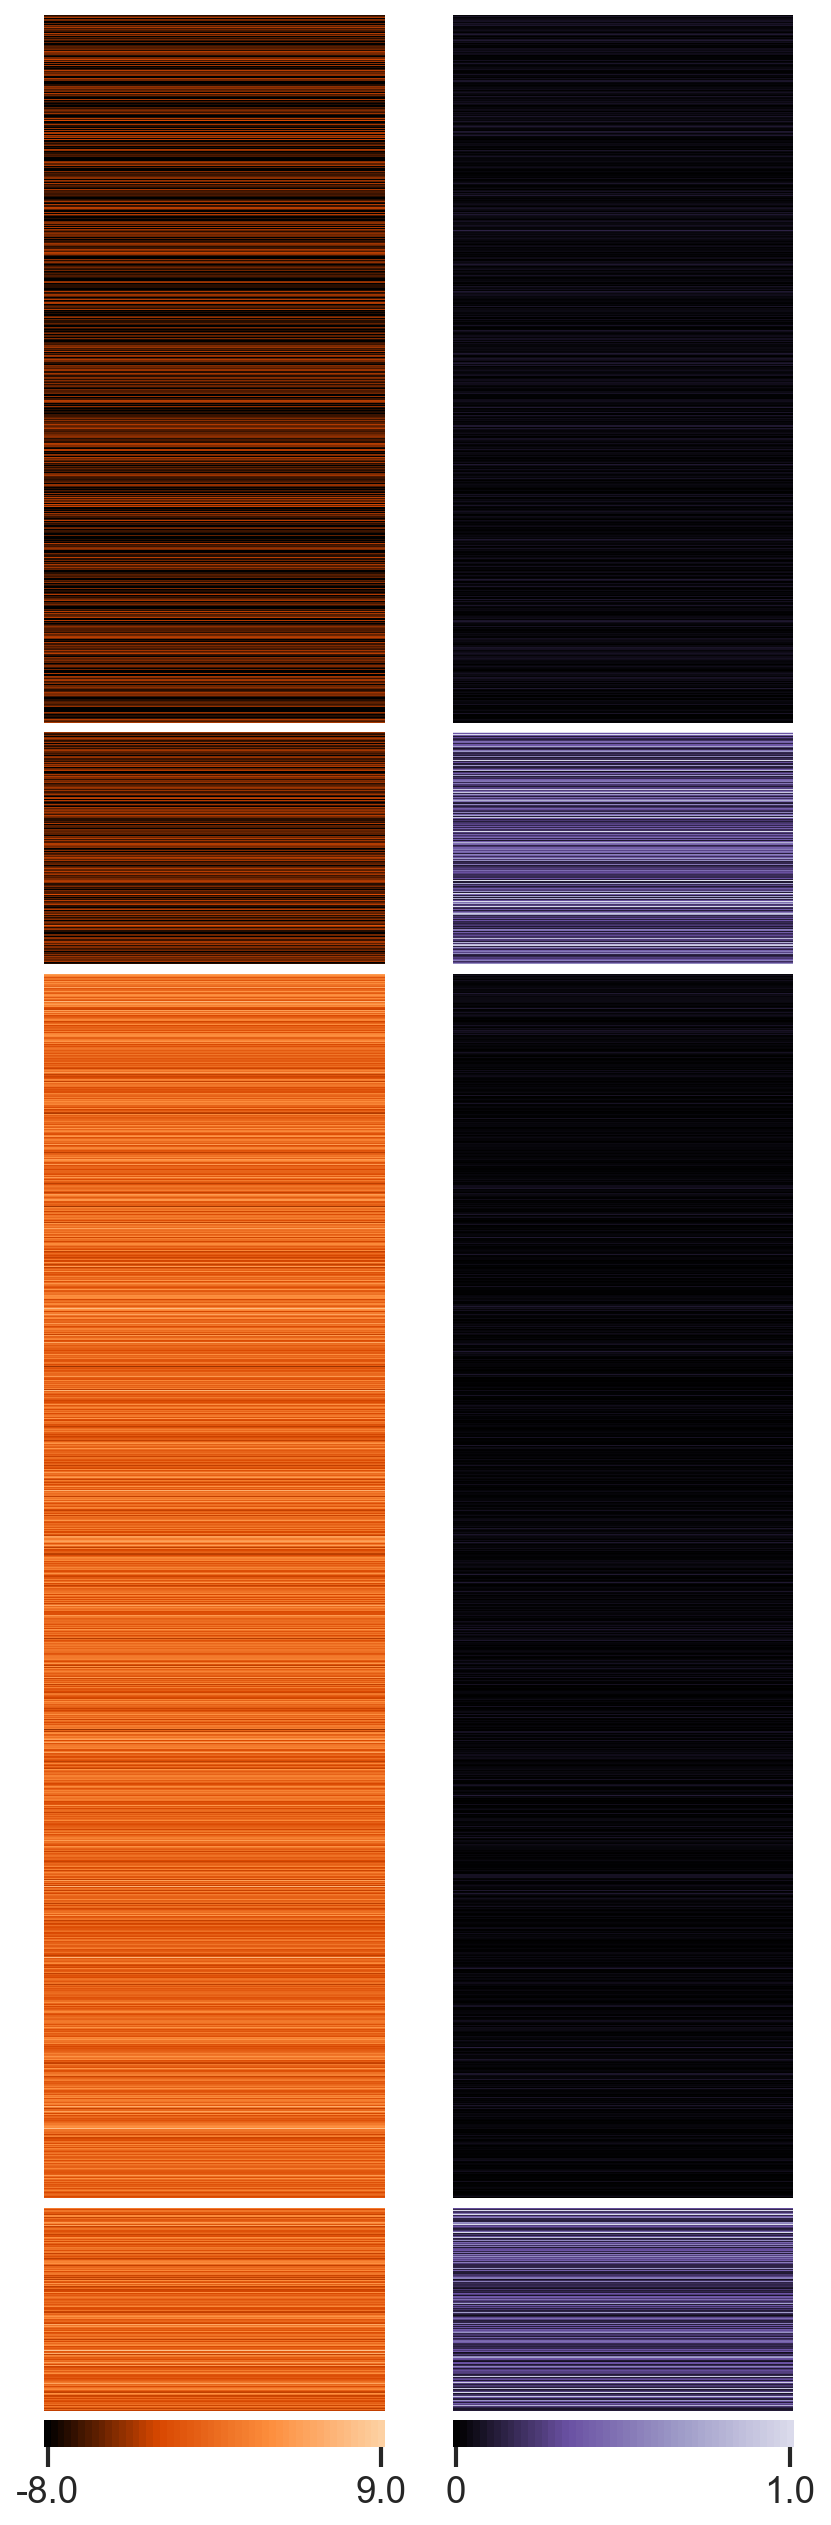

In [64]:
stepheatmap_K27(stepsel='mESCs')
stepheatmap_K27(stepsel='Visceral Endoderm')
stepheatmap_K27(stepsel='Caudal Mesoderm')
stepheatmap_K27(stepsel='Late Motor Neurons')

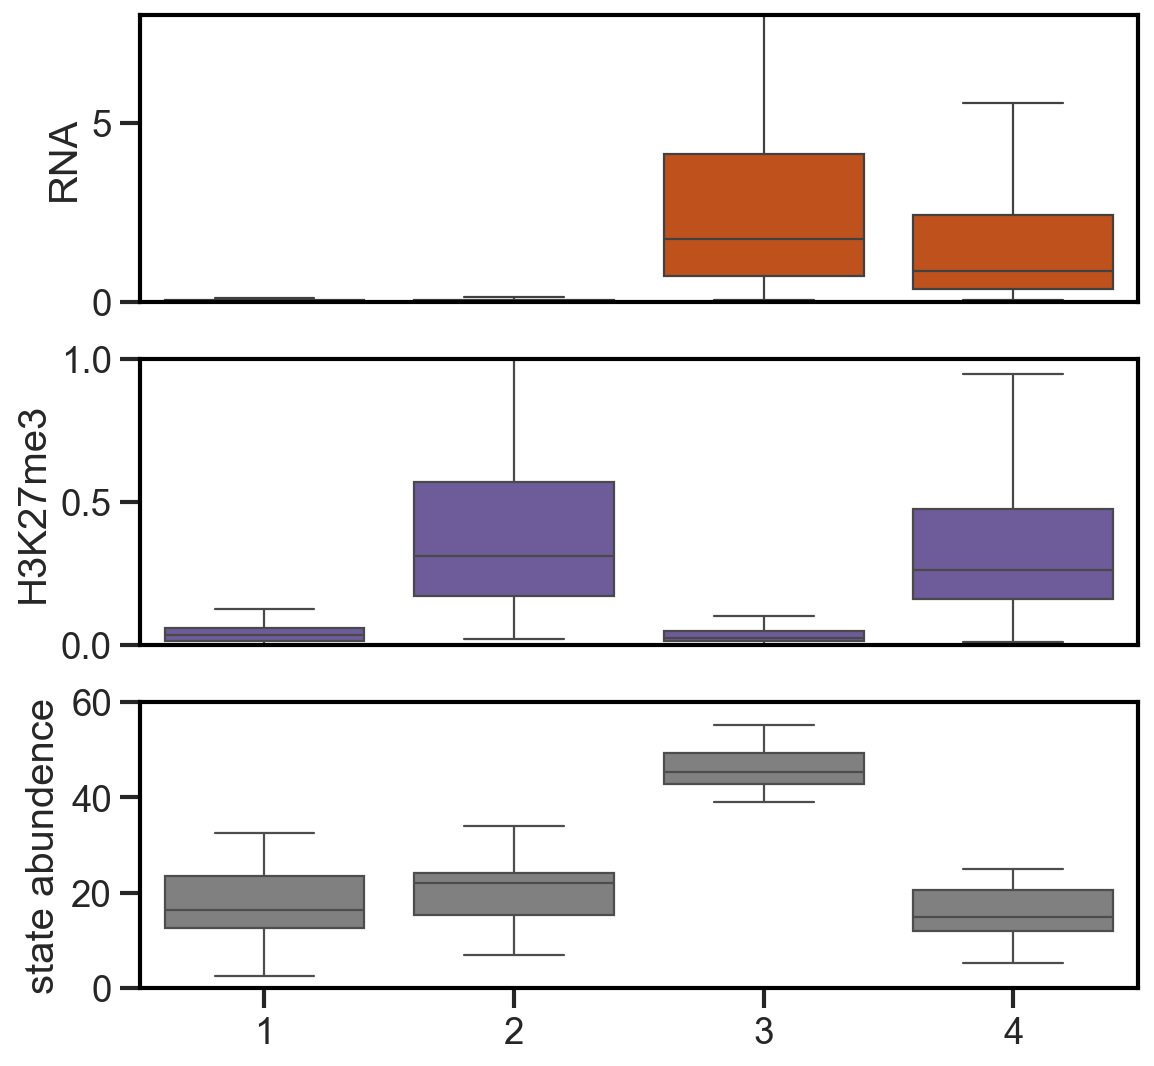

In [65]:

sns.set_context("talk", font_scale=1)
sns.set_style("whitegrid", {'axes.grid' : False, 'xtick.bottom': True,
 'ytick.left': True, 'axes.edgecolor': 'black'})

col='Greys'

fig, axes = plt.subplots(3, 1, figsize=(8, 8), gridspec_kw={})
#plt.figure(figsize=(40,200))
axes = axes.flatten()
#fig.tight_layout(pad=0)




sns.boxplot(data=celltype_pb_counts2, x='K27_full_state', y='RNA', color=Orange, ax=axes[0], fliersize=0)
axes[0].tick_params(labelbottom=False, bottom=False)
axes[0].set_ylim(0, 8)
#axes[0].tick_params(labelleft=False, left=False)
axes[0].set(xlabel='',
       ylabel='RNA',
       title='')


sns.boxplot(data=celltype_pb_counts2, x='K27_full_state', y='K27', color=Purple, ax=axes[1], fliersize=0)
axes[1].tick_params(labelbottom=False, bottom=False)
axes[1].set_ylim(0, 1)
#axes[0].tick_params(labelleft=False, left=False)
axes[1].set(xlabel='',
       ylabel='H3K27me3',
       title='')



plotdata=pd.melt(celltype_pb_meta, id_vars=['celltype'], value_vars=['K27_fr_1','K27_fr_2','K27_fr_3','K27_fr_4'])
plotdata['index']=0
plotdata.loc[plotdata['variable']=='K27_fr_1','index']=1
plotdata.loc[plotdata['variable']=='K27_fr_2','index']=2
plotdata.loc[plotdata['variable']=='K27_fr_3','index']=3
plotdata.loc[plotdata['variable']=='K27_fr_4','index']=4



sns.boxplot(data=plotdata, x='index', y='value', color='Grey', ax=axes[2], fliersize=0)
#axes[3].tick_params(labelbottom=False, bottom=False)
axes[2].set_ylim(0, 60)
#axes[0].tick_params(labelleft=False, left=False)
axes[2].set(xlabel='',
       ylabel='state abundence',
       title='')

plt.savefig('figures/FigS4e_Box_plot_K27_genestates.pdf', dpi=300, format='pdf', bbox_inches='tight')
plt.show()



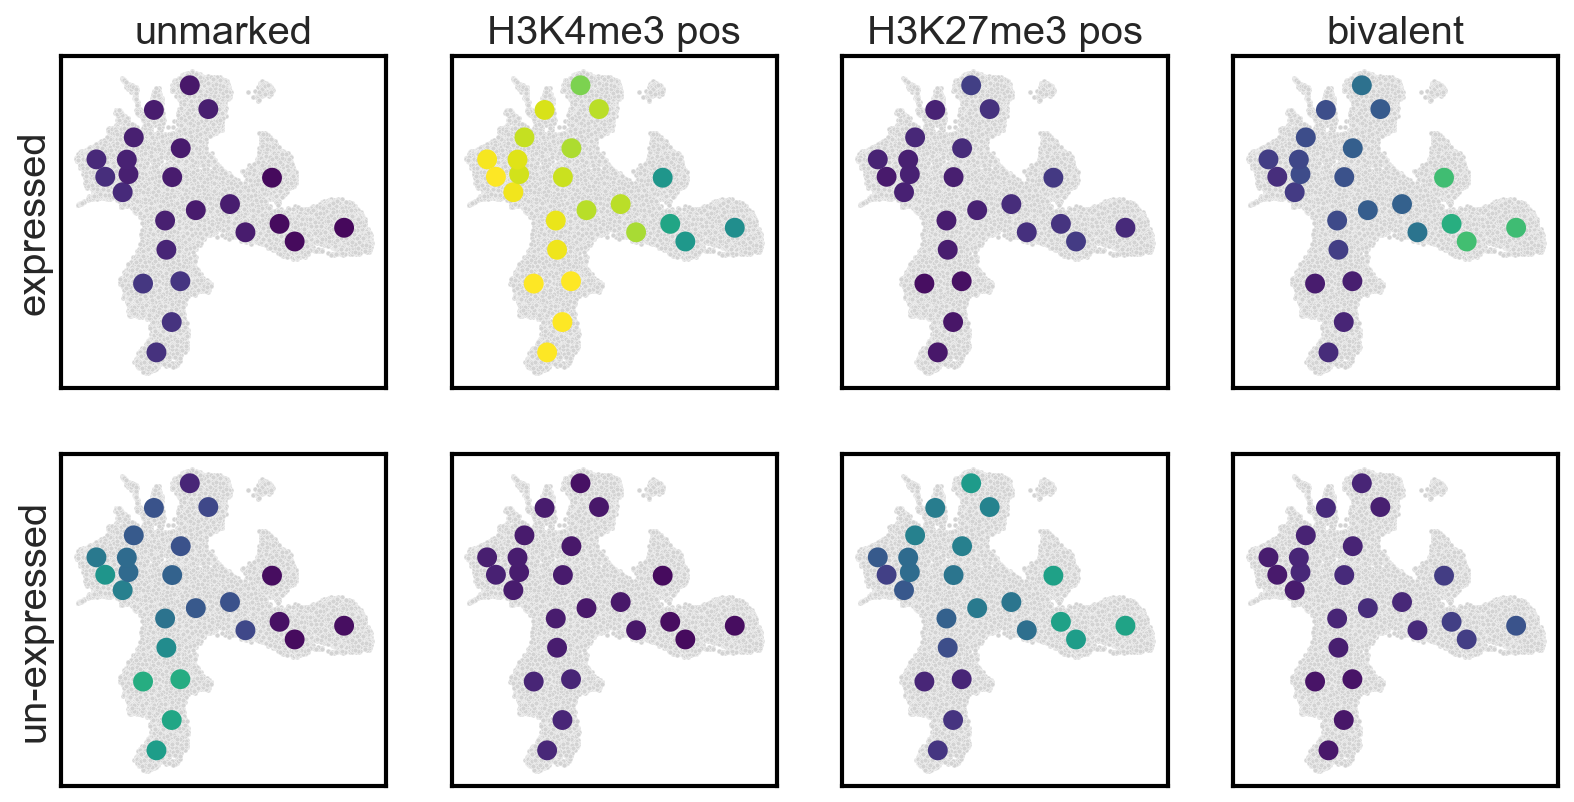

In [66]:

sns.set_context("talk", font_scale=1)
sns.set_style("whitegrid", {'axes.grid' : False, 'xtick.bottom': True,
 'ytick.left': True, 'axes.edgecolor': 'black'})


col='viridis'

fig, axes = plt.subplots(2, 4, figsize=(12, 6), gridspec_kw={})
#plt.figure(figsize=(40,200))
axes = axes.flatten()
#fig.tight_layout(pad=0)

sns.scatterplot(data=UMAP_coord_allcells, x=0, y=1, s=5, color='lightgrey', ax=axes[4], alpha=1)
sns.scatterplot(data=celltype_pb_meta, x='UMAP1', y='UMAP2', s=80, palette=col, hue='fr_1', ax=axes[4], linewidth=0, hue_norm=(0,45), legend=False)
axes[4].tick_params(labelbottom=False, bottom=False)
axes[4].tick_params(labelleft=False, left=False)
axes[4].set(xlabel='',
       ylabel='un-expressed',
       title='')


sns.scatterplot(data=UMAP_coord_allcells, x=0, y=1, s=5, color='lightgrey', ax=axes[5], alpha=1)
sns.scatterplot(data=celltype_pb_meta, x='UMAP1', y='UMAP2', s=80, palette=col, hue='fr_2', ax=axes[5], linewidth=0, hue_norm=(0,45), legend=False)
axes[5].tick_params(labelbottom=False, bottom=False)
axes[5].tick_params(labelleft=False, left=False)
axes[5].set(xlabel='',
       ylabel='',
       title='')

sns.scatterplot(data=UMAP_coord_allcells, x=0, y=1, s=5, color='lightgrey', ax=axes[6], alpha=1)
sns.scatterplot(data=celltype_pb_meta, x='UMAP1', y='UMAP2', s=80, palette=col, hue='fr_3', ax=axes[6], linewidth=0, hue_norm=(0,45), legend=False)
axes[6].tick_params(labelbottom=False, bottom=False)
axes[6].tick_params(labelleft=False, left=False)
axes[6].set(xlabel='',
       ylabel='',
       title='')

sns.scatterplot(data=UMAP_coord_allcells, x=0, y=1, s=5, color='lightgrey', ax=axes[7], alpha=1)
sns.scatterplot(data=celltype_pb_meta, x='UMAP1', y='UMAP2', s=80, palette=col, hue='fr_4', ax=axes[7], linewidth=0, hue_norm=(0,45), legend=False)
axes[7].tick_params(labelbottom=False, bottom=False)
axes[7].tick_params(labelleft=False, left=False)
axes[7].set(xlabel='',
       ylabel='',
       title='')


sns.scatterplot(data=UMAP_coord_allcells, x=0, y=1, s=5, color='lightgrey', ax=axes[0], alpha=1)
sns.scatterplot(data=celltype_pb_meta, x='UMAP1', y='UMAP2', s=80, palette=col, hue='fr_5', ax=axes[0], linewidth=0, hue_norm=(0,45), legend=False)
axes[0].tick_params(labelbottom=False, bottom=False)
axes[0].tick_params(labelleft=False, left=False)
axes[0].set(xlabel='',
       ylabel='expressed',
       title='unmarked')


sns.scatterplot(data=UMAP_coord_allcells, x=0, y=1, s=5, color='lightgrey', ax=axes[1], alpha=1)
sns.scatterplot(data=celltype_pb_meta, x='UMAP1', y='UMAP2', s=80, palette=col, hue='fr_6', ax=axes[1], linewidth=0, hue_norm=(0,45), legend=False)
axes[1].tick_params(labelbottom=False, bottom=False)
axes[1].tick_params(labelleft=False, left=False)
axes[1].set(xlabel='',
       ylabel='',
       title='H3K4me3 pos')

sns.scatterplot(data=UMAP_coord_allcells, x=0, y=1, s=5, color='lightgrey', ax=axes[2], alpha=1)
sns.scatterplot(data=celltype_pb_meta, x='UMAP1', y='UMAP2', s=80, palette=col, hue='fr_7', ax=axes[2], linewidth=0, hue_norm=(0,45), legend=False)
axes[2].tick_params(labelbottom=False, bottom=False)
axes[2].tick_params(labelleft=False, left=False)
axes[2].set(xlabel='',
       ylabel='',
       title='H3K27me3 pos')

sns.scatterplot(data=UMAP_coord_allcells, x=0, y=1, s=5, color='lightgrey', ax=axes[3], alpha=1)
sns.scatterplot(data=celltype_pb_meta, x='UMAP1', y='UMAP2', s=80, palette=col, hue='fr_8', ax=axes[3], linewidth=0, hue_norm=(0,45), legend=False)
axes[3].tick_params(labelbottom=False, bottom=False)
axes[3].tick_params(labelleft=False, left=False)
axes[3].set(xlabel='',
       ylabel='',
       title='bivalent')




plt.savefig('figures/Fig4c_UMAP_all_8_states_200cells_pb.png', dpi=300, format='png', bbox_inches='tight')
plt.show()


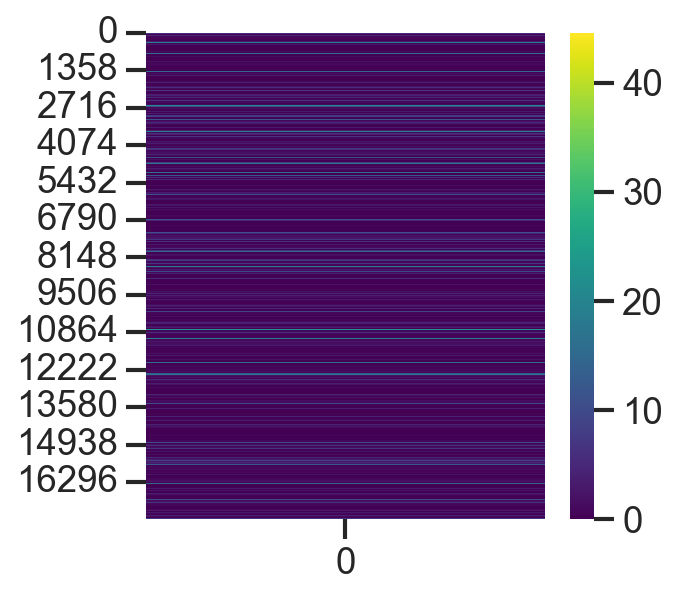

In [67]:
#colorlegend for Fig4c
sns.heatmap(celltype_pb_counts2.loc[((celltype_pb_counts2['celltype']=='PGCs')&(celltype_pb_counts2['RNA']<=45)), 'RNA'].values.reshape((1, -1)).T, cmap='viridis')

plt.savefig('figures/Fig4c_cmap.pdf', dpi=300, format='pdf', bbox_inches='tight')
plt.show()

In [68]:
#plot example heatmaps of 3 data layers split by class
def stepheatmap_all(stepsel):

    RNAlayerlog='RNA_log2'
    K4layer='K4'
    K27layer='K27'
    
    
    plotdata=celltype_pb_counts2.loc[celltype_pb_counts2['celltype']==stepsel].copy()

    
    l1=plotdata[((plotdata['RNA_gene_state']==0)&(plotdata['K4_gene_state']==0)&(plotdata['K27_gene_state']==0))]['gene']
    l2=plotdata[((plotdata['RNA_gene_state']==0)&(plotdata['K4_gene_state']==0)&(plotdata['K27_gene_state']==1))]['gene']
    l3=plotdata[((plotdata['RNA_gene_state']==0)&(plotdata['K4_gene_state']==1)&(plotdata['K27_gene_state']==0))]['gene']
    l4=plotdata[((plotdata['RNA_gene_state']==0)&(plotdata['K4_gene_state']==1)&(plotdata['K27_gene_state']==1))]['gene']
    l5=plotdata[((plotdata['RNA_gene_state']==1)&(plotdata['K4_gene_state']==0)&(plotdata['K27_gene_state']==0))]['gene']
    l6=plotdata[((plotdata['RNA_gene_state']==1)&(plotdata['K4_gene_state']==0)&(plotdata['K27_gene_state']==1))]['gene']
    l7=plotdata[((plotdata['RNA_gene_state']==1)&(plotdata['K4_gene_state']==1)&(plotdata['K27_gene_state']==0))]['gene']
    l8=plotdata[((plotdata['RNA_gene_state']==1)&(plotdata['K4_gene_state']==1)&(plotdata['K27_gene_state']==1))]['gene']

    
    sns.set_context("talk", font_scale=1)
    sns.set_style("whitegrid", {'axes.grid' : False, 'xtick.bottom': True,
     'ytick.left': True, 'axes.edgecolor': 'black'})
    
    pc=0.001
    fig, axes = plt.subplots(9, 3, figsize=(10, 20), gridspec_kw={'hspace': 0.04 ,'width_ratios':(1,1,1),'height_ratios':(len(l1)+pc,len(l2)+pc,len(l3)+pc,len(l4)+pc,len(l5)+pc,len(l6)+pc,len(l7)+pc,len(l8)+pc,200)})
    #plt.figure(figsize=(40,200))
    axes = axes.flatten()
    #fig.tight_layout(pad=0)
    
    
    RNAvmaxlog=(celltype_pb_counts2[RNAlayerlog]).quantile(q=1)
    RNAvminlog=(celltype_pb_counts2[RNAlayerlog]).min()
    k4vmax=(celltype_pb_counts2[K4layer]).quantile(q=0.95)
    k27vmax=(celltype_pb_counts2[K27layer]).quantile(q=0.97)
    
    
    
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l1)),RNAlayerlog].values.reshape((1, -1)).T, ax=axes[0], cmap=oranges_r, cbar=False, vmin=RNAvminlog, vmax=RNAvmaxlog)
    axes[0].tick_params(labelleft=False, left=False)
    axes[0].tick_params(labelbottom=False, bottom=False)
    axes[0].set(xlabel='',
           ylabel='',
           title='')
    
    
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l1)),K4layer].values.reshape((1, -1)).T, ax=axes[1], cmap=greens_r, cbar=False, vmin=0, vmax=k4vmax)
    axes[1].tick_params(labelleft=False, left=False)
    axes[1].tick_params(labelbottom=False, bottom=False)
    axes[1].set(xlabel='',
           ylabel='',
           title='')
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l1)),K27layer].values.reshape((1, -1)).T, ax=axes[2], cmap=purples_r, cbar=False, vmin=0, vmax=k27vmax)
    axes[2].tick_params(labelleft=False, left=False)
    axes[2].tick_params(labelbottom=False, bottom=False)
    axes[2].set(xlabel='',
           ylabel='',
           title='')
    
    
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l2)),RNAlayerlog].values.reshape((1, -1)).T, ax=axes[3], cmap=oranges_r, cbar=False, vmin=RNAvminlog, vmax=RNAvmaxlog)
    axes[3].tick_params(labelleft=False, left=False)
    axes[3].tick_params(labelbottom=False, bottom=False)
    axes[3].set(xlabel='',
           ylabel='',
           title='')
    
    
    
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l2)),K4layer].values.reshape((1, -1)).T, ax=axes[4], cmap=greens_r, cbar=False, vmin=0, vmax=k4vmax)
    axes[4].tick_params(labelleft=False, left=False)
    axes[4].tick_params(labelbottom=False, bottom=False)
    axes[4].set(xlabel='',
           ylabel='',
           title='')
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l2)),K27layer].values.reshape((1, -1)).T, ax=axes[5], cmap=purples_r, cbar=False, vmin=0, vmax=k27vmax)
    axes[5].tick_params(labelleft=False, left=False)
    axes[5].tick_params(labelbottom=False, bottom=False)
    axes[5].set(xlabel='',
           ylabel='',
           title='')
    
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l3)),RNAlayerlog].values.reshape((1, -1)).T, ax=axes[6], cmap=oranges_r, cbar=False, vmin=RNAvminlog, vmax=RNAvmaxlog)
    axes[6].tick_params(labelleft=False, left=False)
    axes[6].tick_params(labelbottom=False, bottom=False)
    axes[6].set(xlabel='',
           ylabel='',
           title='')
    
    
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l3)),K4layer].values.reshape((1, -1)).T, ax=axes[7], cmap=greens_r, cbar=False, vmin=0, vmax=k4vmax)
    axes[7].tick_params(labelleft=False, left=False)
    axes[7].tick_params(labelbottom=False, bottom=False)
    axes[7].set(xlabel='',
           ylabel='',
           title='')
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l3)),K27layer].values.reshape((1, -1)).T, ax=axes[8], cmap=purples_r, cbar=False, vmin=0, vmax=k27vmax)
    axes[8].tick_params(labelleft=False, left=False)
    axes[8].tick_params(labelbottom=False, bottom=False)
    axes[8].set(xlabel='',
           ylabel='',
           title='')
    
    
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l4)),RNAlayerlog].values.reshape((1, -1)).T, ax=axes[9], cmap=oranges_r, cbar=False, vmin=RNAvminlog, vmax=RNAvmaxlog)
    axes[9].tick_params(labelleft=False, left=False)
    axes[9].tick_params(labelbottom=False, bottom=False)
    axes[9].set(xlabel='',
           ylabel='',
           title='')
    
   
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l4)),K4layer].values.reshape((1, -1)).T, ax=axes[10], cmap=greens_r, cbar=False, vmin=0, vmax=k4vmax)
    axes[10].tick_params(labelleft=False, left=False)
    axes[10].tick_params(labelbottom=False, bottom=False)
    axes[10].set(xlabel='',
           ylabel='',
           title='')
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l4)),K27layer].values.reshape((1, -1)).T, ax=axes[11], cmap=purples_r, cbar=False, vmin=0, vmax=k27vmax)
    axes[11].tick_params(labelleft=False, left=False)
    axes[11].tick_params(labelbottom=False, bottom=False)
    axes[11].set(xlabel='',
           ylabel='',
           title='')
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l5)),RNAlayerlog].values.reshape((1, -1)).T, ax=axes[12], cmap=oranges_r, cbar=False, vmin=RNAvminlog, vmax=RNAvmaxlog)
    axes[12].tick_params(labelleft=False, left=False)
    axes[12].tick_params(labelbottom=False, bottom=False)
    axes[12].set(xlabel='',
           ylabel='',
           title='')
    
    
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l5)),K4layer].values.reshape((1, -1)).T, ax=axes[13], cmap=greens_r, cbar=False, vmin=0, vmax=k4vmax)
    axes[13].tick_params(labelleft=False, left=False)
    axes[13].tick_params(labelbottom=False, bottom=False)
    axes[13].set(xlabel='',
           ylabel='',
           title='')
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l5)),K27layer].values.reshape((1, -1)).T, ax=axes[14], cmap=purples_r, cbar=False, vmin=0, vmax=k27vmax)
    axes[14].tick_params(labelleft=False, left=False)
    axes[14].tick_params(labelbottom=False, bottom=False)
    axes[14].set(xlabel='',
           ylabel='',
           title='')
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l6)),RNAlayerlog].values.reshape((1, -1)).T, ax=axes[15], cmap=oranges_r, cbar=False, vmin=RNAvminlog, vmax=RNAvmaxlog)
    axes[15].tick_params(labelleft=False, left=False)
    axes[15].tick_params(labelbottom=False, bottom=False)
    axes[15].set(xlabel='',
           ylabel='',
           title='')
    
    
    
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l6)),K4layer].values.reshape((1, -1)).T, ax=axes[16], cmap=greens_r, cbar=False, vmin=0, vmax=k4vmax)
    axes[16].tick_params(labelleft=False, left=False)
    axes[16].tick_params(labelbottom=False, bottom=False)
    axes[16].set(xlabel='',
           ylabel='',
           title='')
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l6)),K27layer].values.reshape((1, -1)).T, ax=axes[17], cmap=purples_r, cbar=False, vmin=0, vmax=k27vmax)
    axes[17].tick_params(labelleft=False, left=False)
    axes[17].tick_params(labelbottom=False, bottom=False)
    axes[17].set(xlabel='',
           ylabel='',
           title='')
    
    
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l7)),RNAlayerlog].values.reshape((1, -1)).T, ax=axes[18], cmap=oranges_r, cbar=False, vmin=RNAvminlog, vmax=RNAvmaxlog)
    axes[18].tick_params(labelleft=False, left=False)
    axes[18].tick_params(labelbottom=False, bottom=False)
    axes[18].set(xlabel='',
           ylabel='',
           title='')
    
    
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l7)),K4layer].values.reshape((1, -1)).T, ax=axes[19], cmap=greens_r, cbar=False, vmin=0, vmax=k4vmax)
    axes[19].tick_params(labelleft=False, left=False)
    axes[19].tick_params(labelbottom=False, bottom=False)
    axes[19].set(xlabel='',
           ylabel='',
           title='')
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l7)),K27layer].values.reshape((1, -1)).T, ax=axes[20], cmap=purples_r, cbar=False, vmin=0, vmax=k27vmax)
    axes[20].tick_params(labelleft=False, left=False)
    axes[20].tick_params(labelbottom=False, bottom=False)
    axes[20].set(xlabel='',
           ylabel='',
           title='')
    
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l8)),RNAlayerlog].values.reshape((1, -1)).T, ax=axes[21], cmap=oranges_r, cbar=False, vmin=RNAvminlog, vmax=RNAvmaxlog)
    axes[21].tick_params(labelleft=False, left=False)
    axes[21].tick_params(labelbottom=False, bottom=False)
    axes[21].set(xlabel='',
           ylabel='',
           title='')
    
    
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l8)),K4layer].values.reshape((1, -1)).T, ax=axes[22], cmap=greens_r, cbar=False, vmin=0, vmax=k4vmax)
    axes[22].tick_params(labelleft=False, left=False)
    axes[22].tick_params(labelbottom=False, bottom=False)
    axes[22].set(xlabel='',
           ylabel='',
           title='')
    
    sns.heatmap(plotdata.loc[(plotdata['gene'].isin(l8)),K27layer].values.reshape((1, -1)).T, ax=axes[23], cmap=purples_r, cbar=False, vmin=0, vmax=k27vmax)
    axes[23].tick_params(labelleft=False, left=False)
    axes[23].tick_params(labelbottom=False, bottom=False)
    axes[23].set(xlabel='',
           ylabel='',
           title='')
    
    
    gradient = np.linspace(round(RNAvminlog,0), round(RNAvmaxlog,0)).reshape(1, -1)
    axes[24].imshow(gradient, aspect="auto", cmap=oranges_r)
    axes[24].set_yticks([])
    axes[24].set_frame_on(False)
    axes[24].set_xticks([0, gradient.size-1])  # Positions along the gradient
    axes[24].set_xticklabels([round(RNAvminlog,0), round(RNAvmaxlog,0)])  # Labels
    
    
    gradient = np.linspace(0, round(k4vmax,1)).reshape(1, -1)
    axes[25].imshow(gradient, aspect="auto", cmap=greens_r)
    axes[25].set_yticks([])
    axes[25].set_frame_on(False)
    axes[25].set_xticks([0, gradient.size-1])  # Positions along the gradient
    axes[25].set_xticklabels([0, round(k4vmax,1)])  # Labels
    
    gradient = np.linspace(0, round(k27vmax,1)).reshape(1, -1)
    axes[26].imshow(gradient, aspect="auto", cmap=purples_r)
    axes[26].set_yticks([])
    axes[26].set_frame_on(False)
    axes[26].set_xticks([0, gradient.size-1])  # Positions along the gradient
    axes[26].set_xticklabels([0, round(k27vmax,1)])  # Labels
    
    filename1='figures/Fig5b_Stateheatmap_'+stepsel+'.png'
    filename2='figures/Fig5b_Stateheatmap_'+stepsel+'.pdf'
    
    plt.savefig(filename1, dpi=300, format='png', bbox_inches='tight')
    plt.savefig(filename2, dpi=300, format='pdf', bbox_inches='tight')
    plt.show()

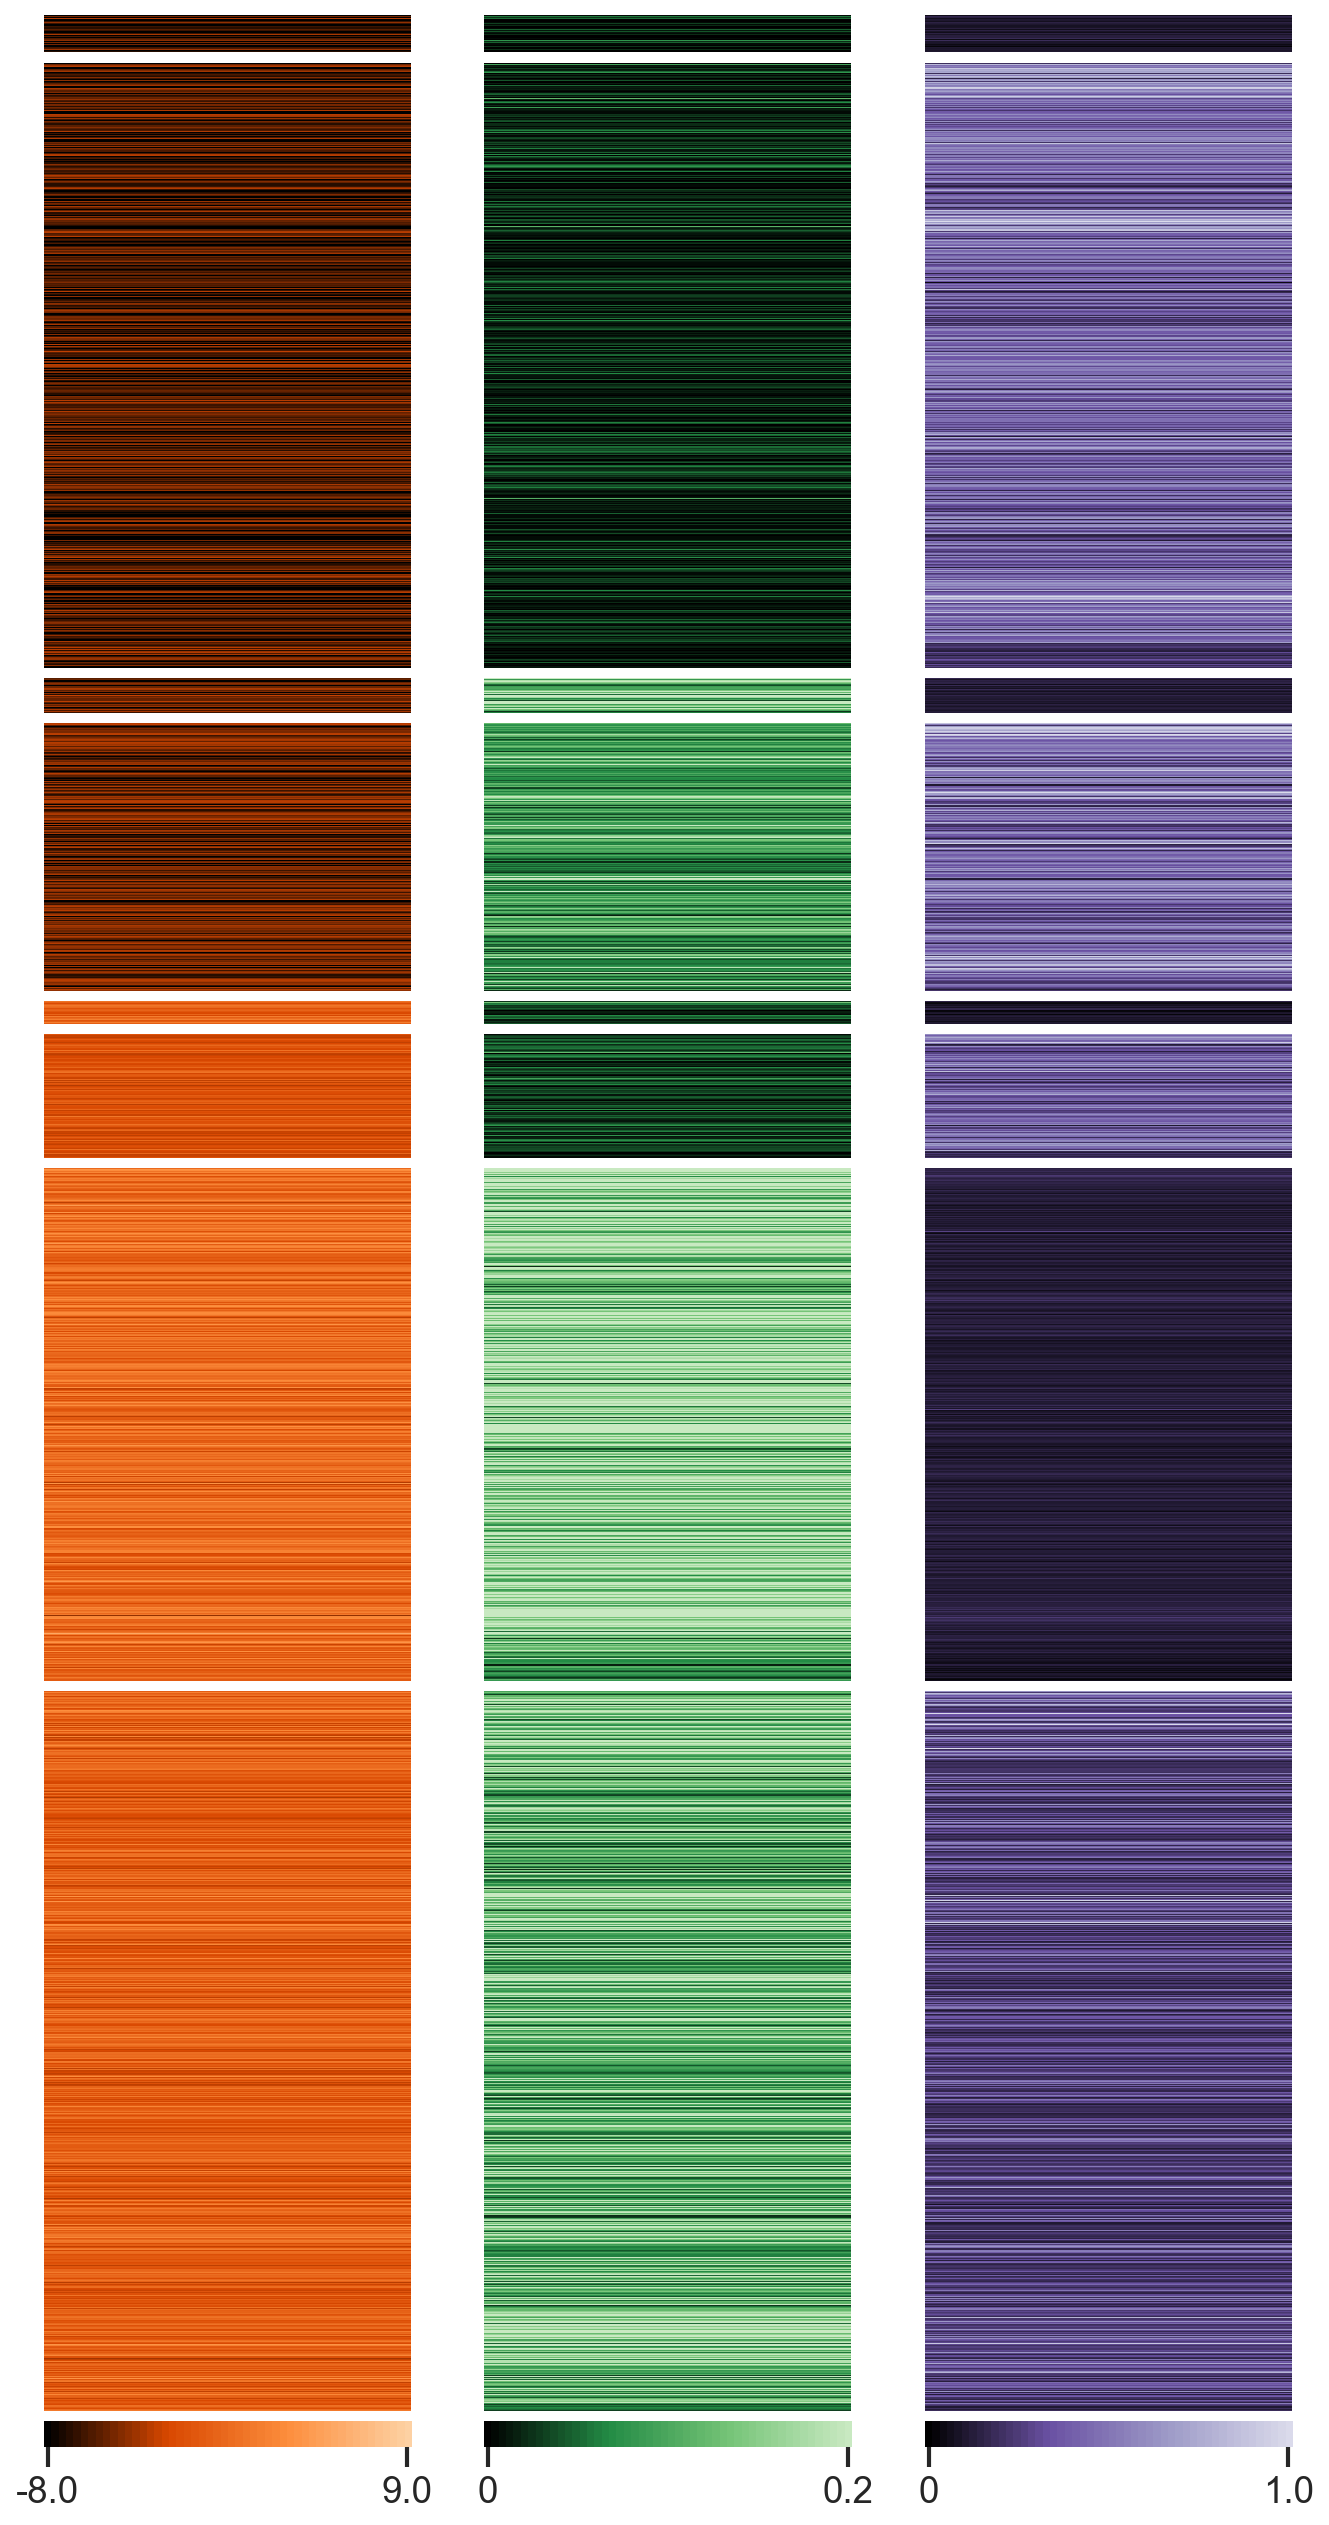

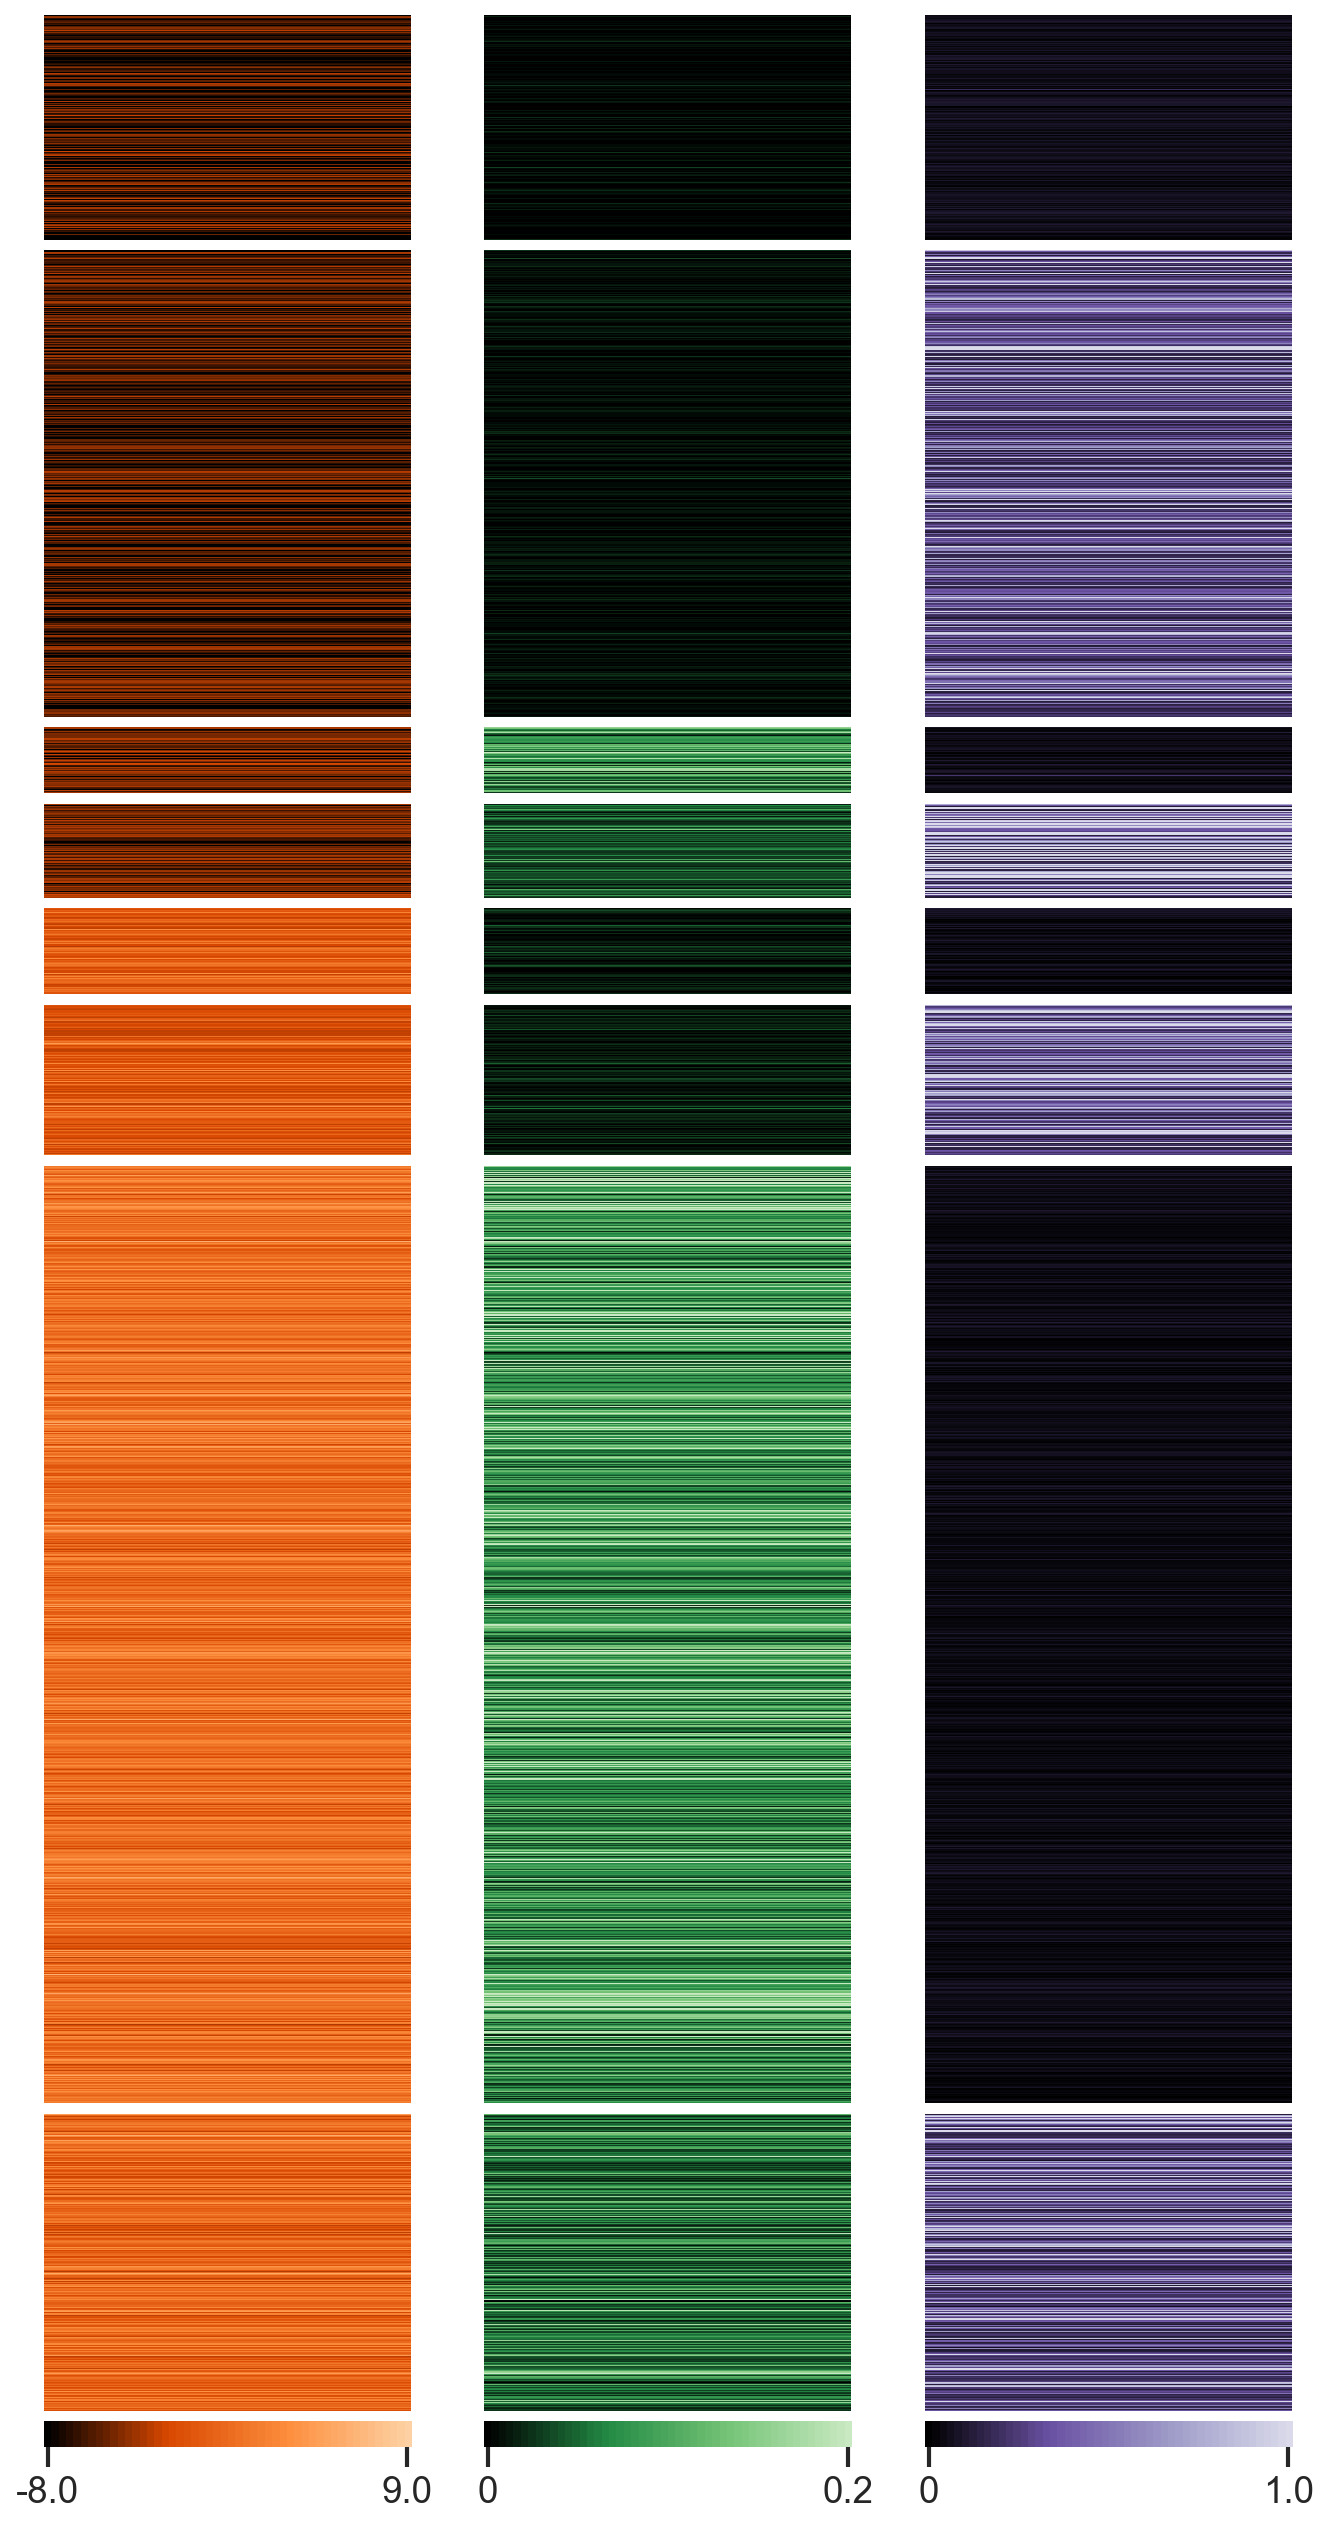

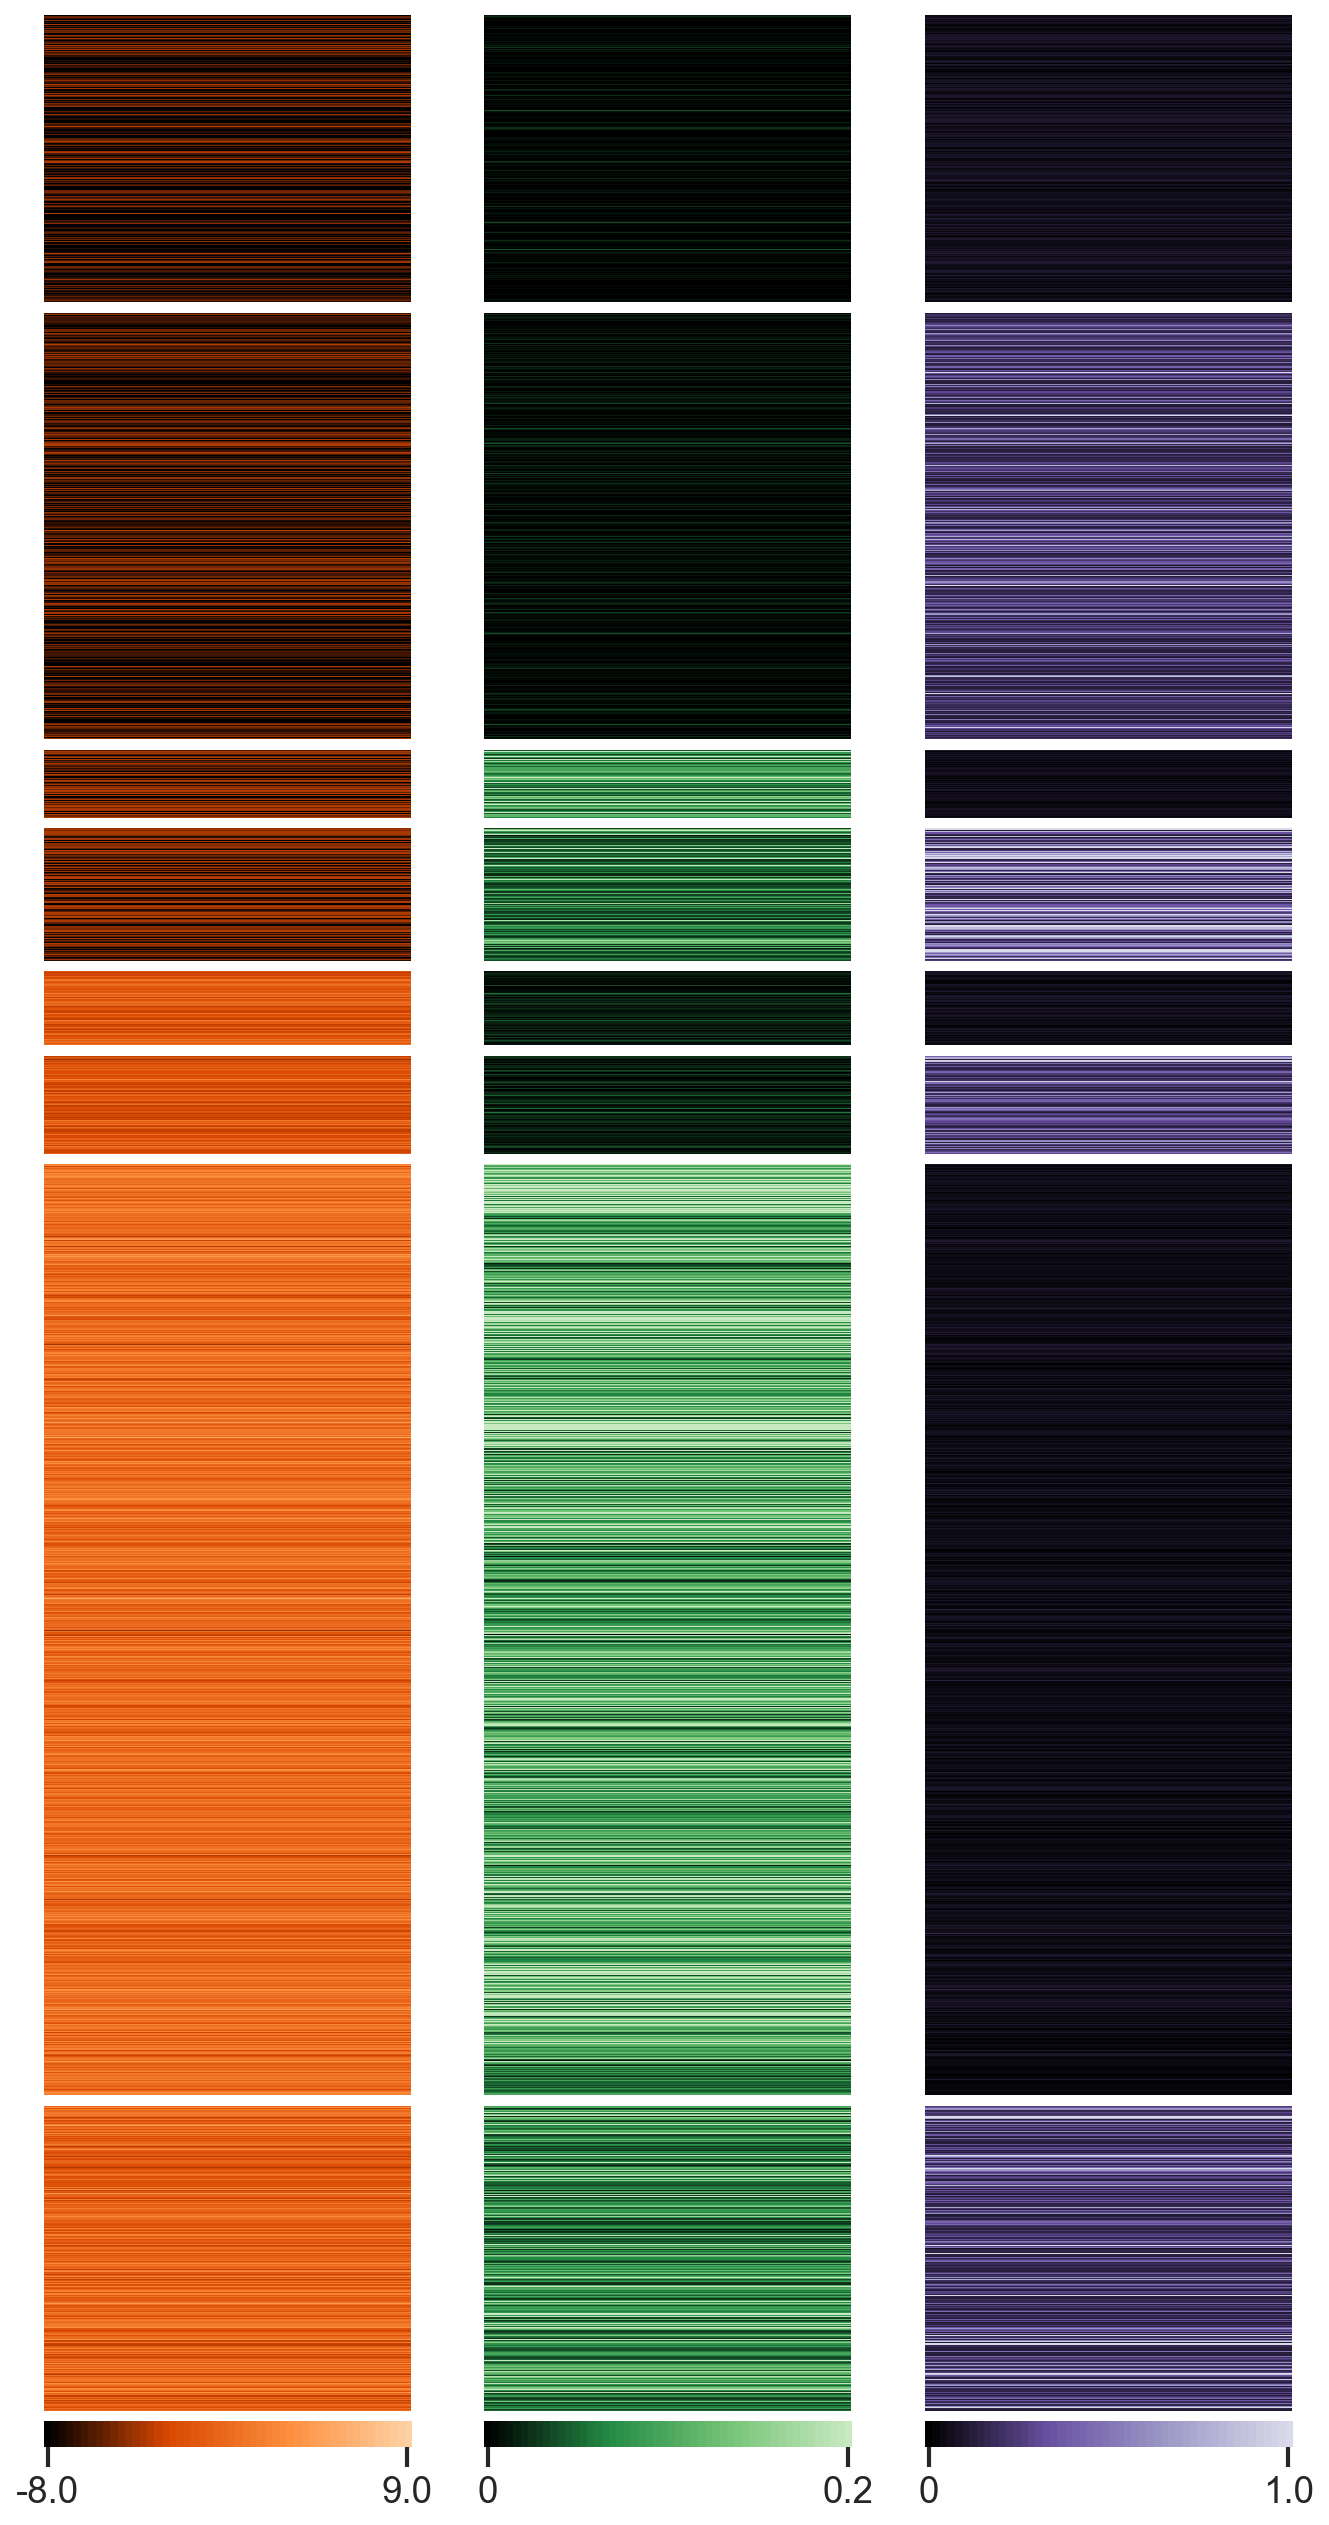

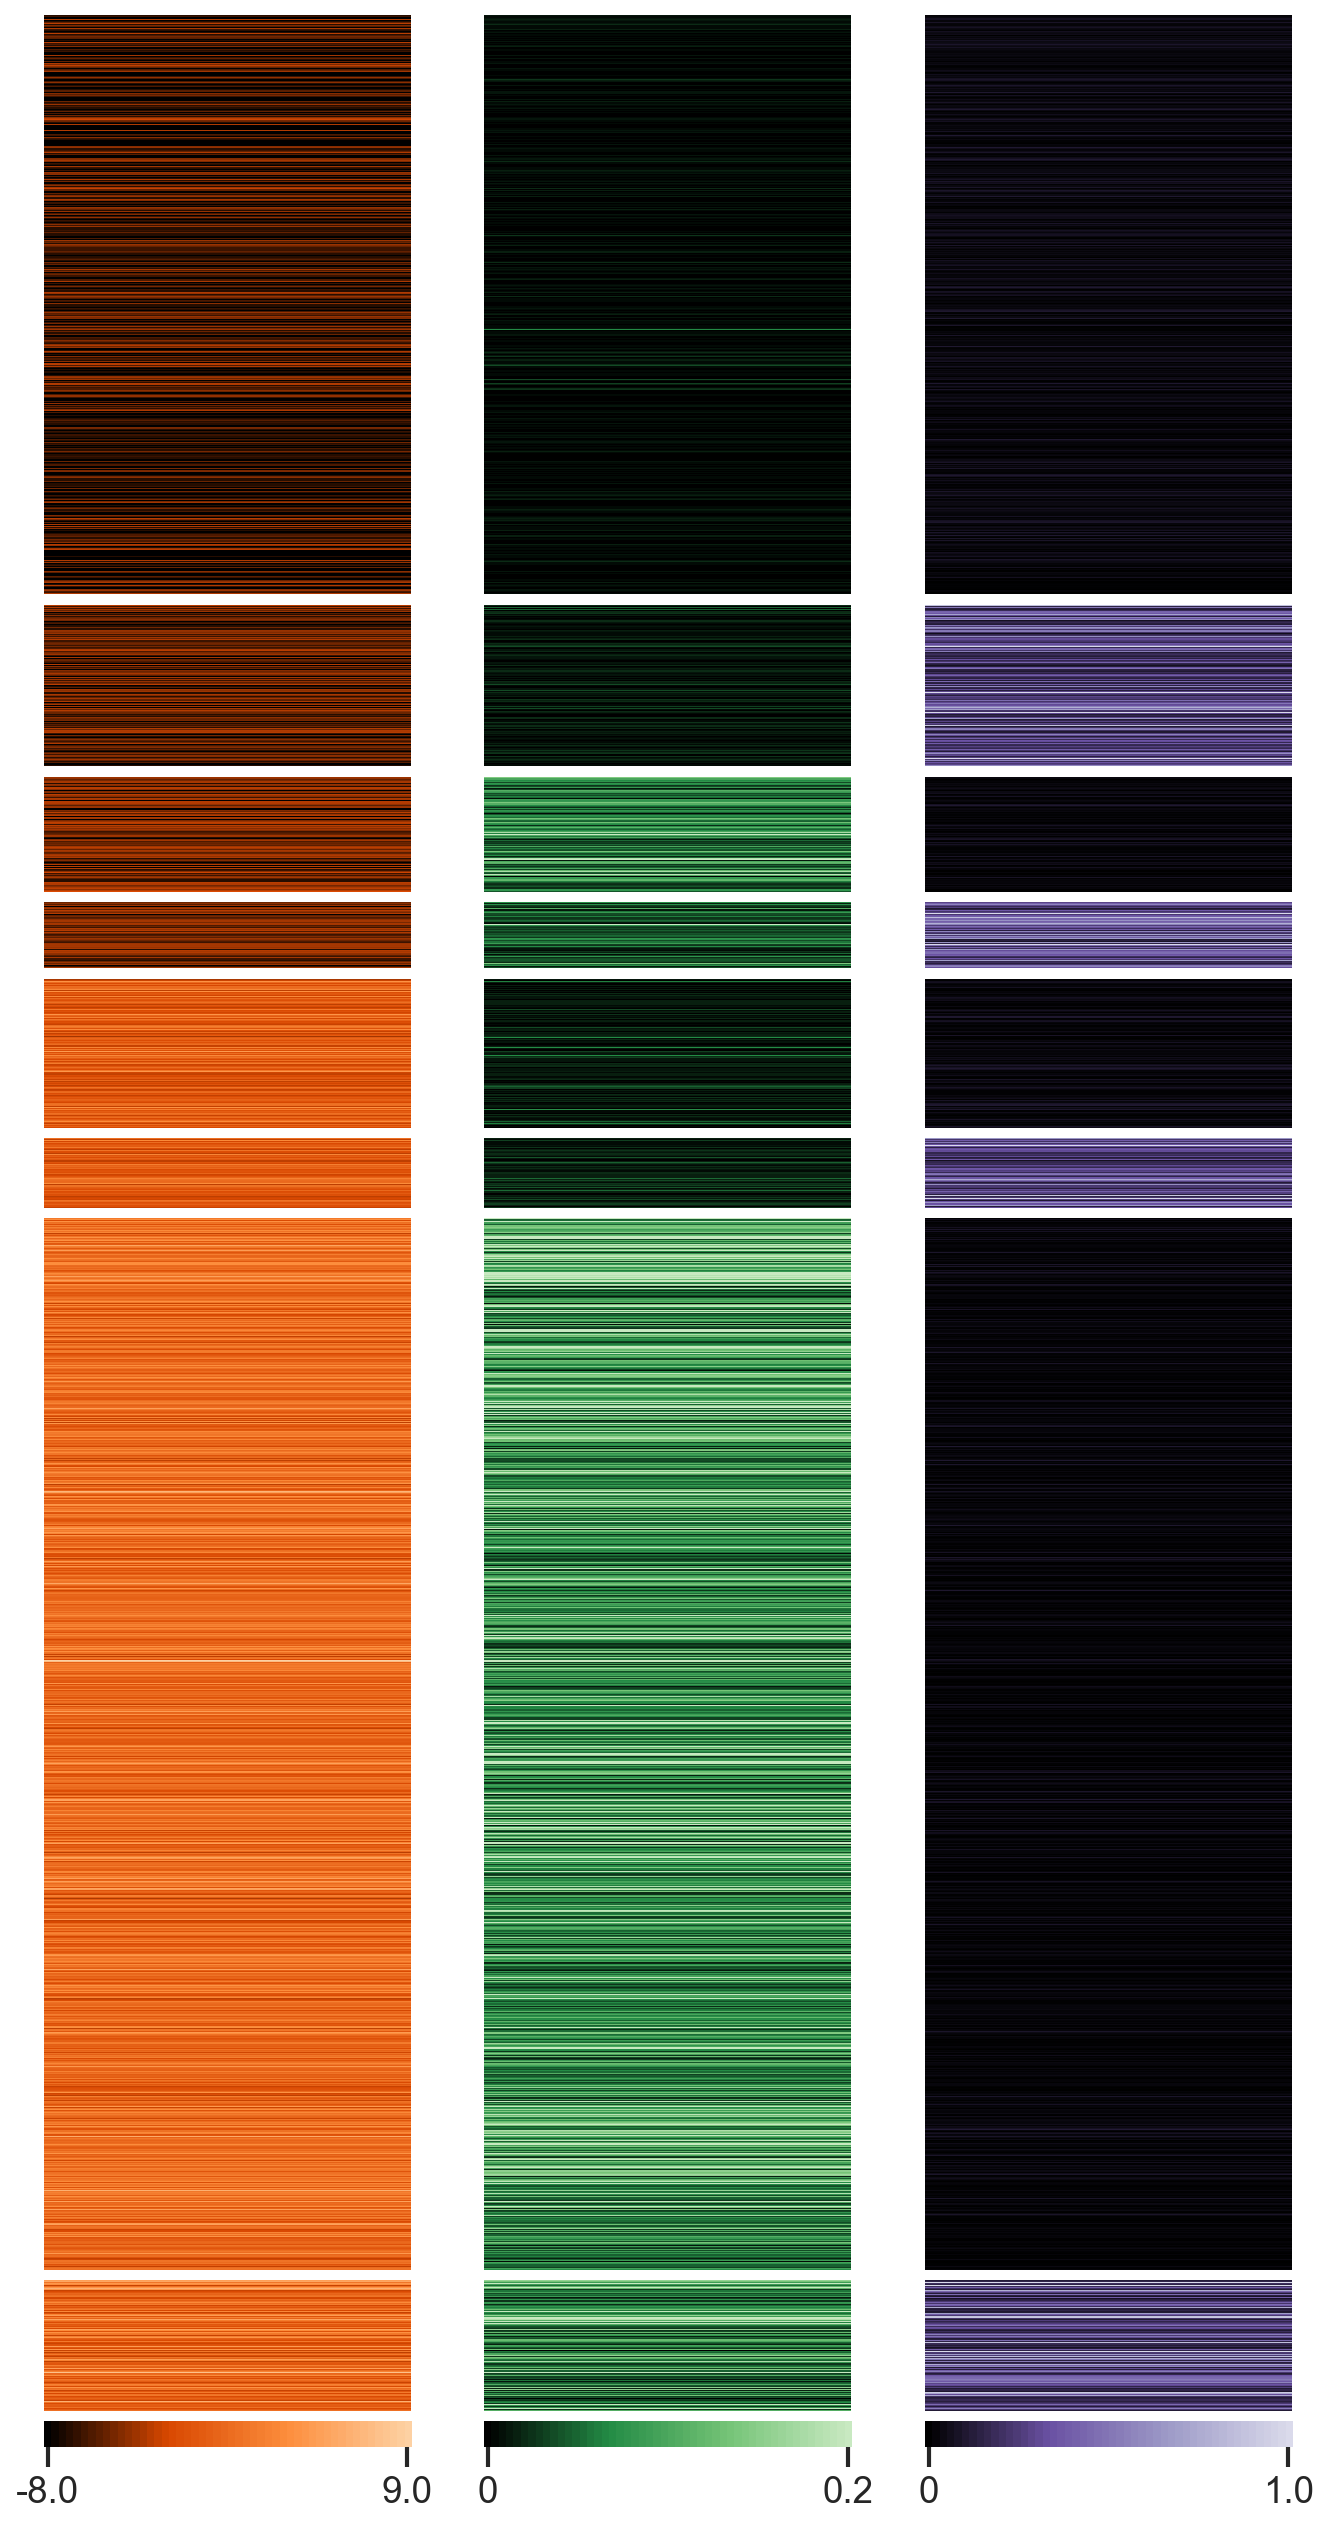

In [69]:
stepheatmap_all(stepsel='mESCs')
stepheatmap_all(stepsel='Visceral Endoderm')
stepheatmap_all(stepsel='Caudal Mesoderm')
stepheatmap_all(stepsel='Late Motor Neurons')

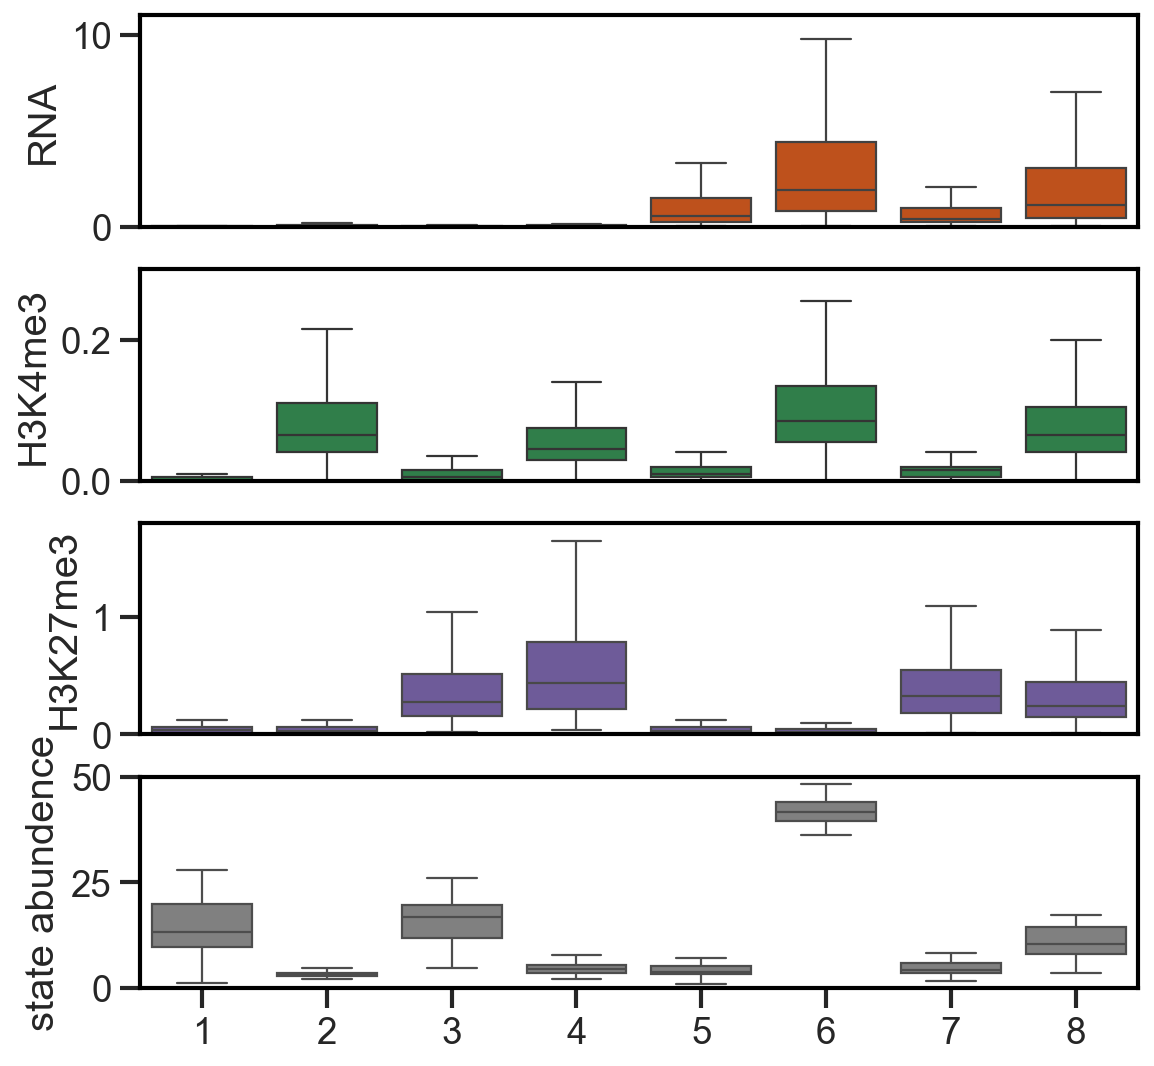

In [70]:

sns.set_context("talk", font_scale=1)
sns.set_style("whitegrid", {'axes.grid' : False, 'xtick.bottom': True,
 'ytick.left': True, 'axes.edgecolor': 'black'})

col='Greys'

fig, axes = plt.subplots(4, 1, figsize=(8, 8), gridspec_kw={})
#plt.figure(figsize=(40,200))
axes = axes.flatten()
#fig.tight_layout(pad=0)




sns.boxplot(data=celltype_pb_counts2, x='full_state', y='RNA', color=Orange, ax=axes[0], fliersize=0)
axes[0].tick_params(labelbottom=False, bottom=False)
axes[0].set_ylim(0, 11)
#axes[0].tick_params(labelleft=False, left=False)
axes[0].set(xlabel='',
       ylabel='RNA',
       title='')


sns.boxplot(data=celltype_pb_counts2, x='full_state', y='K4', color=Green, ax=axes[1], fliersize=0)
axes[1].tick_params(labelbottom=False, bottom=False)
axes[1].set_ylim(0, 0.3)
#axes[0].tick_params(labelleft=False, left=False)
axes[1].set(xlabel='',
       ylabel='H3K4me3',
       title='')


sns.boxplot(data=celltype_pb_counts2, x='full_state', y='K27', color=Purple, ax=axes[2], fliersize=0)
axes[2].tick_params(labelbottom=False, bottom=False)
axes[2].set_ylim(0, 1.8)
#axes[0].tick_params(labelleft=False, left=False)
axes[2].set(xlabel='',
       ylabel='H3K27me3',
       title='')

plotdata=pd.melt(celltype_pb_meta, id_vars=['celltype'], value_vars=['fr_1','fr_2','fr_3','fr_4','fr_5','fr_6','fr_7','fr_8'])
plotdata['index']=0
plotdata.loc[plotdata['variable']=='fr_1','index']=1
plotdata.loc[plotdata['variable']=='fr_2','index']=2
plotdata.loc[plotdata['variable']=='fr_3','index']=3
plotdata.loc[plotdata['variable']=='fr_4','index']=4
plotdata.loc[plotdata['variable']=='fr_5','index']=5
plotdata.loc[plotdata['variable']=='fr_6','index']=6
plotdata.loc[plotdata['variable']=='fr_7','index']=7
plotdata.loc[plotdata['variable']=='fr_8','index']=8


sns.boxplot(data=plotdata, x='index', y='value', color='Grey', ax=axes[3], fliersize=0)
#axes[3].tick_params(labelbottom=False, bottom=False)
axes[3].set_ylim(0, 50)
#axes[0].tick_params(labelleft=False, left=False)
axes[3].set(xlabel='',
       ylabel='state abundence',
       title='')

plt.savefig('figures/FigS5a_Box_plot_genestates.pdf', dpi=300, format='pdf', bbox_inches='tight')
plt.show()



In [71]:
adata.obs['K27_prom_to_total']=(adata[adata.obs['mark']=='H3K27me3'].obs['K27_prom']/adata[adata.obs['mark']=='H3K27me3'].obs['K27_total'])*100
adata.obs['K4_prom_to_total']=(adata[adata.obs['mark']=='H3K4me3'].obs['K4_prom']/adata[adata.obs['mark']=='H3K4me3'].obs['K4_total'])*100

In [72]:
#select samples for plotting

daylist=['Pluripotent mESCs','Pluripotent Gastd3','Pluripotent Gastd4','Endoderm Gastd5','Endoderm Gastd6','Endoderm Gastd7','Mesoderm Gastd5',
        'Mesoderm Gastd6','Mesoderm Gastd7','Ectoderm Gastd5','Ectoderm Gastd6','Ectoderm Gastd7']
K27adata=adata[((adata.obs['mark']=='H3K27me3')&(adata.obs['lin_day'].isin(daylist)))]


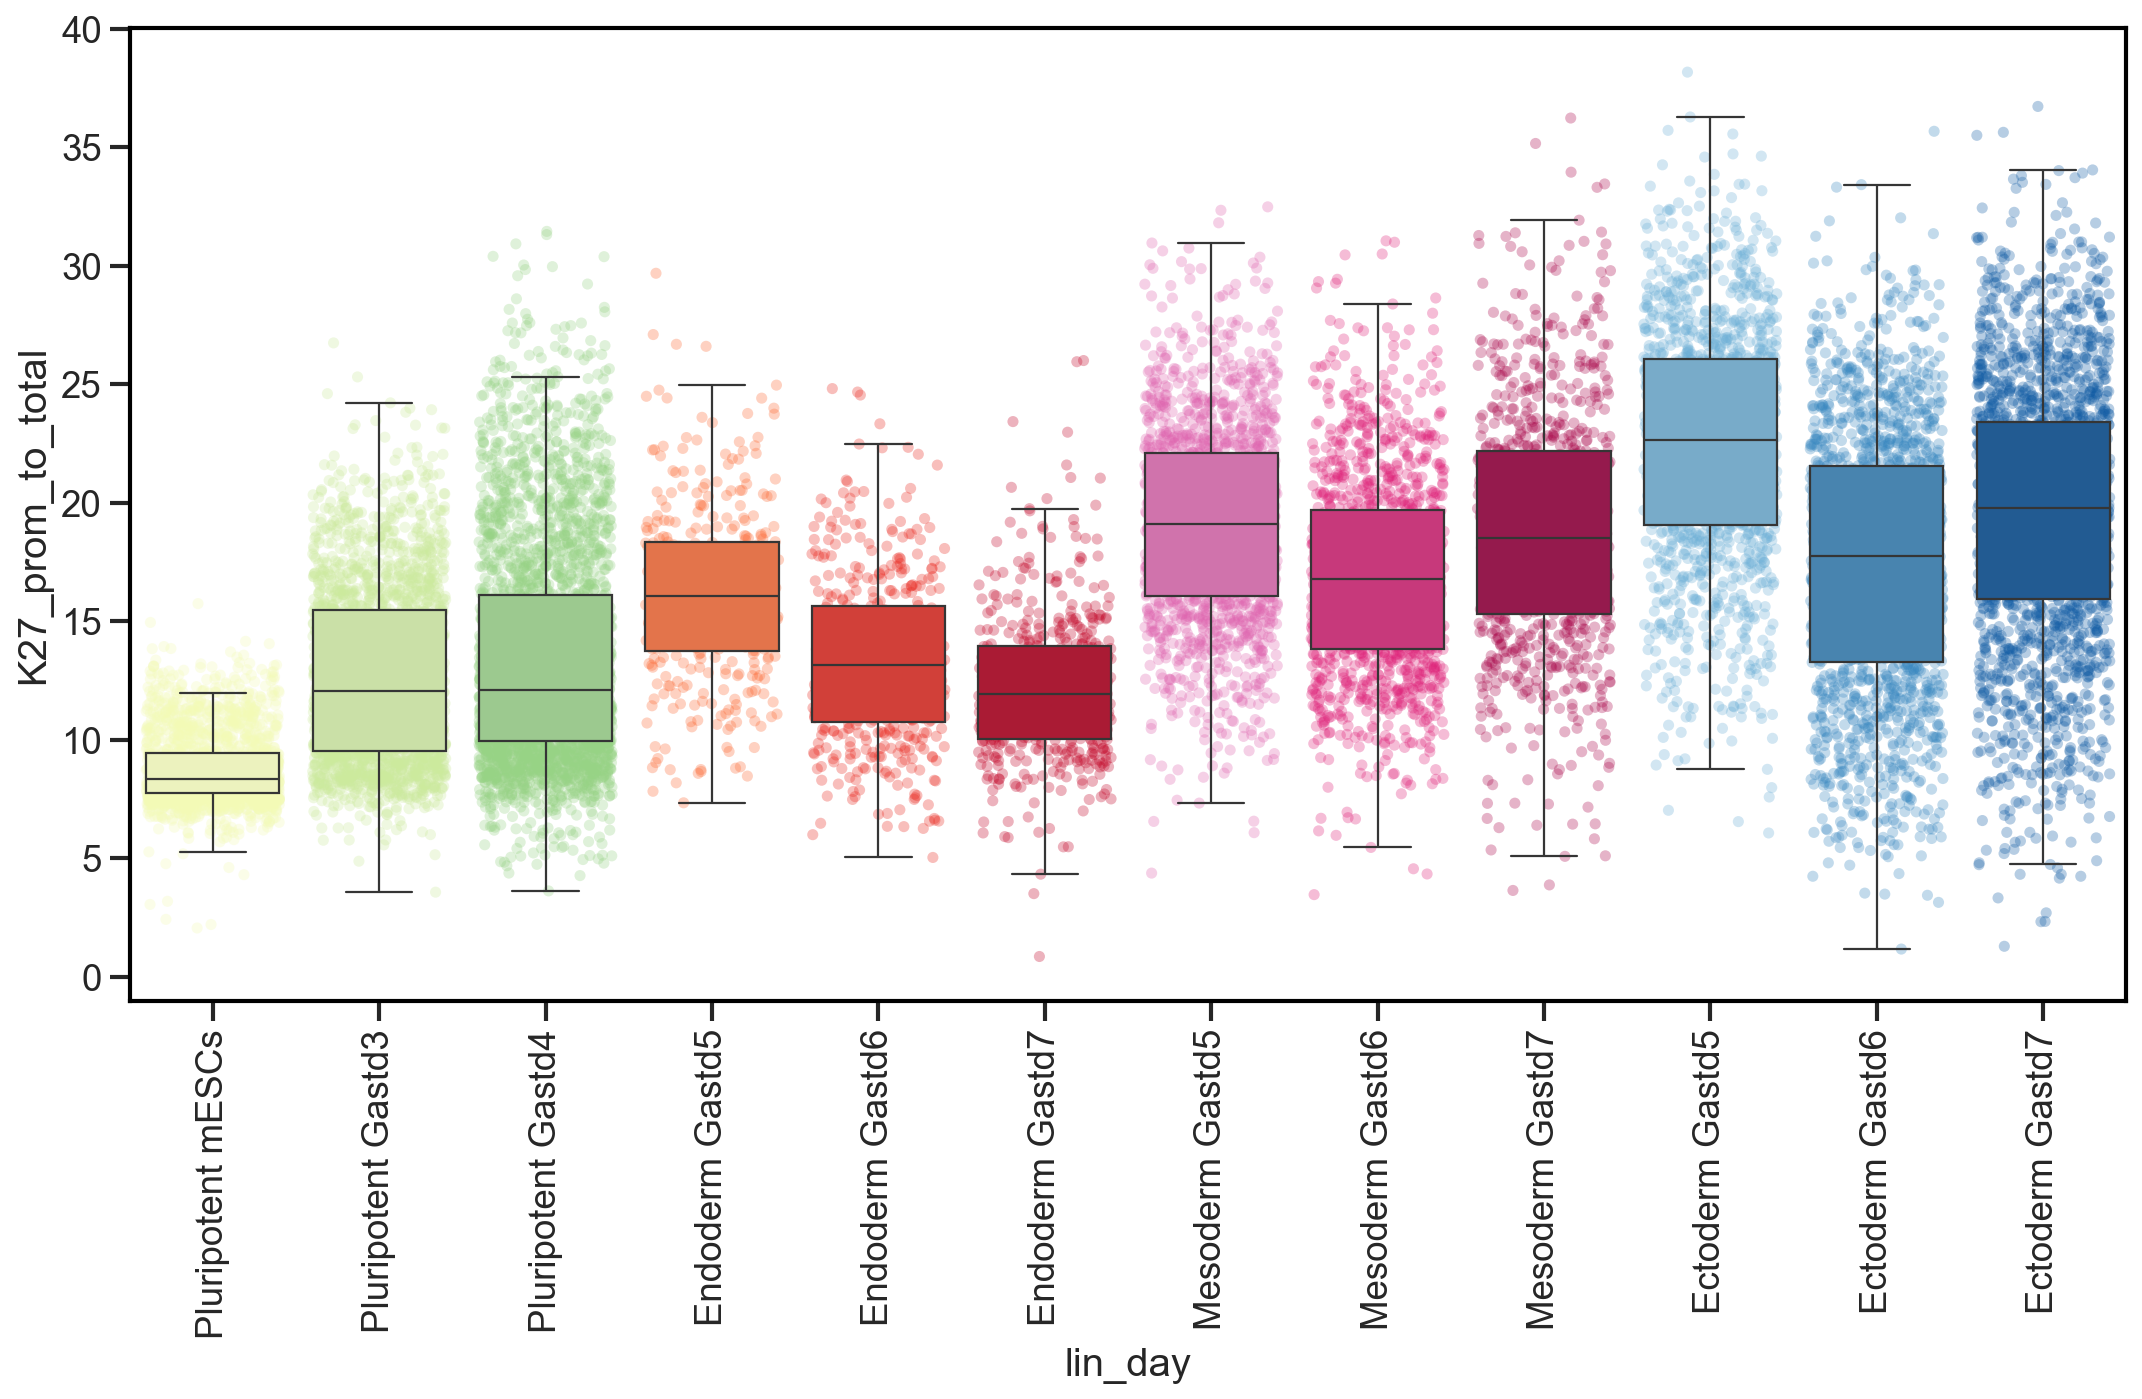

In [73]:
fig, axes = plt.subplots(1, 1, figsize=(16, 8), gridspec_kw={})


sns.stripplot(data=K27adata.obs, x='lin_day', y='K27_prom_to_total', zorder=0, order=daylist ,ax=axes, jitter=0.4, hue='lin_day',palette=K27adata.uns['lin_day_colors'].tolist(), alpha=0.3)
sns.boxplot(data=K27adata.obs, x='lin_day', y='K27_prom_to_total', zorder=2, order=daylist ,ax=axes, dodge=False, hue='lin_day' ,palette=K27adata.uns['lin_day_colors'].tolist(), fliersize=0)

plt.xticks(rotation=90)
plt.savefig('figures/FigS5c_boxplot_H3K27me3_prom_div_Lin_day.pdf', dpi=300, format='pdf', bbox_inches='tight')
plt.savefig('figures/FigS5c_boxplot_H3K27me3_prom_div_Lin_day.png', dpi=300, format='png', bbox_inches='tight')
plt.show()

saving figure to file figures\dotplot_FigS5d_left_Dotplot_epimodifiers_transf_K4_K27.pdf


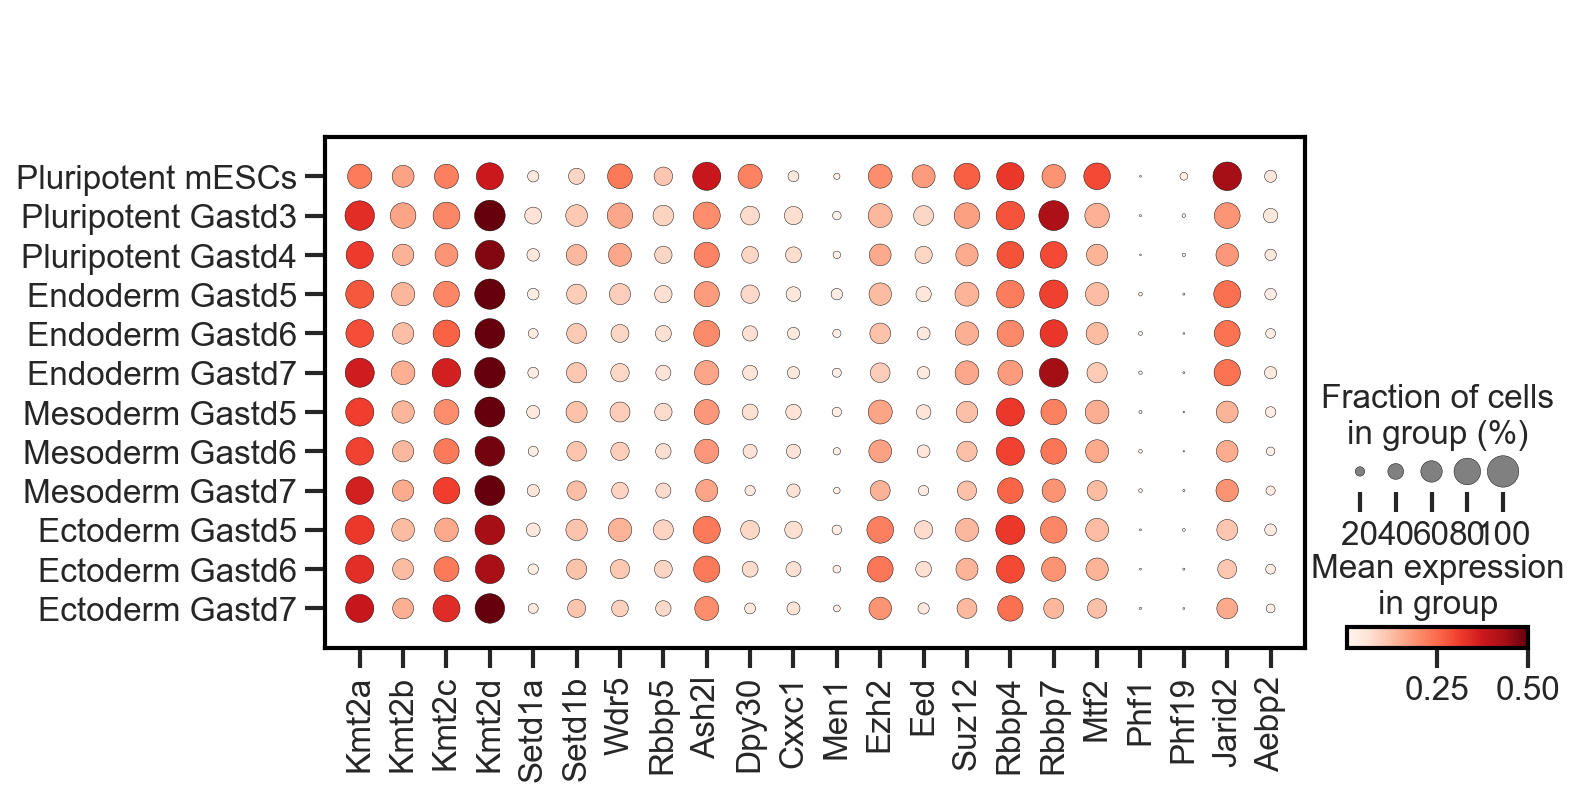

In [74]:
markers = ['Kmt2a','Kmt2b','Kmt2c','Kmt2d','Setd1a','Setd1b',    #K4me catalytic
           'Wdr5','Rbbp5','Ash2l','Dpy30','Cxxc1','Men1',    #K4me core
           'Ezh2', 'Eed', 'Suz12','Rbbp4', 'Rbbp7',    #PRC2 core
           'Mtf2','Phf1','Phf19',     #PRC2.1
           'Jarid2','Aebp2'    #PRC2.2
           

]
celltypeorder=['Pluripotent mESCs','Pluripotent Gastd3','Pluripotent Gastd4','Endoderm Gastd5','Endoderm Gastd6','Endoderm Gastd7','Mesoderm Gastd5',
        'Mesoderm Gastd6','Mesoderm Gastd7','Ectoderm Gastd5','Ectoderm Gastd6','Ectoderm Gastd7']
sc.settings.figdir = 'figures'

sc.pl.dotplot(adata[adata.obs['lin_day'].isin(celltypeorder)], markers, groupby='lin_day', vmax=0.5, categories_order=celltypeorder, save='FigS5d_left_Dotplot_epimodifiers_transf_K4_K27.pdf')




saving figure to file figures\dotplot_FigS5d_right_Dotplot_epimodifiers_removel_K4_K27.pdf


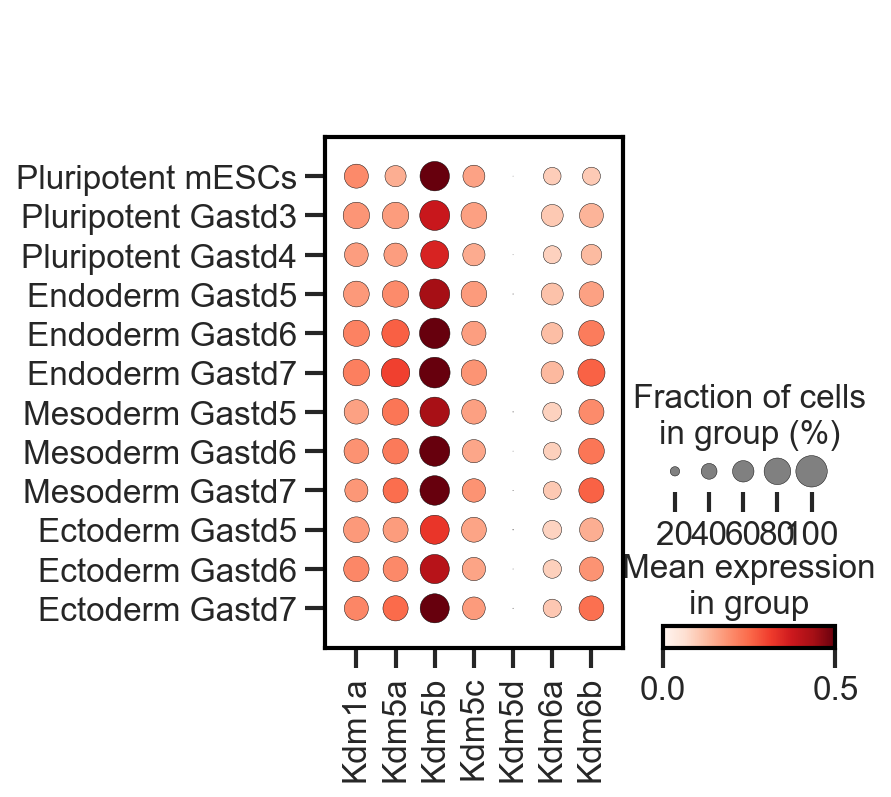

In [75]:
markers = ['Kdm1a','Kdm5a','Kdm5b','Kdm5c', 'Kdm5d',    #K4me
           'Kdm6a','Kdm6b' #K27me

]
celltypeorder=['Pluripotent mESCs','Pluripotent Gastd3','Pluripotent Gastd4','Endoderm Gastd5','Endoderm Gastd6','Endoderm Gastd7','Mesoderm Gastd5',
        'Mesoderm Gastd6','Mesoderm Gastd7','Ectoderm Gastd5','Ectoderm Gastd6','Ectoderm Gastd7']
sc.settings.figdir = 'figures'

sc.pl.dotplot(adata[adata.obs['lin_day'].isin(celltypeorder)], markers, groupby='lin_day', vmax=0.5, categories_order=celltypeorder, save='FigS5d_right_Dotplot_epimodifiers_removel_K4_K27.pdf')


